# Advanced Apex Project-1 (M.Sc. Data Science & AI)

## 1. Project Title & Student Details

### **Project Title**: Predicting Telco Customer Churn Using Historical Customer and Service Attributes

### **Student Details**
- **Name:** Gaurav Kumar Singh  
- **BITS ID:** 2025EM1200007    
- **Course:** MDSDF480 Advanced Apex Project I  

## 2. Problem Statement & Business Goal

**Problem Statement**

Customer churn reduces revenue and increases acquisition costs for telecom companies. The challenge is to identify customers at risk of leaving early enough to intervene effectively.

---

**Business Goal**

Develop a classification model that predicts churn so the business can target retention efforts toward high-risk customers.

## 3. Dataset Description

### 3.1 Dataset Details

- **Dataset Name:** Telco Customer Churn  

- **Source:** Kaggle
- **Dataset Size:** 7,043 rows and 21 columns *(including target variable)*
- **Target Variable:** `Churn`  
- **Type:** Binary classification


### 3.2 Dataset Loading

In [1]:
# Purpose: Download the Telco Customer Churn dataset from KaggleHub,locate the CSV file, load it into a Pandas DataFrame and verify successful loading.

# Importing all required libraries
from pathlib import Path          # Handles file and directory paths
import sys                        # Provides access to Python runtime information
import subprocess                 # Executes system commands from Python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure KaggleHub is available, if not installed, install it automatically and import again
try:
    import kagglehub
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "kagglehub"]
    )
    import kagglehub

# Download Telco Customer Churn dataset from KaggleHub
dataset_dir = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)


# Search recursively for all CSV files inside the downloaded dataset directory
csv_candidates = sorted(
    Path(dataset_dir).rglob("*.csv")
)


# Validate that at least one CSV file exists, Raise an error if no dataset file is found
if not csv_candidates:
    raise FileNotFoundError(
        f"No CSV file found inside downloaded dataset directory: {dataset_dir}"
    )


# Select the first available CSV file
csv_path = csv_candidates[0]

# Load dataset into a Pandas DataFrame
df = pd.read_csv(csv_path)


# Display dataset information for verification
print(f"\nDataset directory: {dataset_dir}")
print(f"\nCSV file used: {csv_path}")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.

Dataset directory: /kaggle/input/telco-customer-churn

CSV file used: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


### 3.3 Initial Dataset Preview

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.4 Data Dictionary

| Column Name | Data Type | Non-Null Count | Null Count | Unique Values | Description |  Role | Primary Key |
|--------------|-----------|---------------:|-----------:|--------------:|-------------|--------------|-------------|
| customerID | object | 7043 | 0 | 7043 | A unique ID that identifies each customer. | Identifier | Y |
| gender | object | 7043 | 0 | 2 | Customer gender. | Feature | N |
| SeniorCitizen | int64 | 7043 | 0 | 2 | Binary indicator for senior citizen status. | Feature | N |
| Partner | object | 7043 | 0 | 2 | Whether the customer has a partner. | Feature | N |
| Dependents | object | 7043 | 0 | 2 | Whether the customer has dependents. | Feature | N |
| tenure | int64 | 7043 | 0 | 73 | Number of months the customer has stayed with the company. | Feature | N |
| PhoneService | object | 7043 | 0 | 2 | Whether the customer subscribes to phone service. | Feature | N |
| MultipleLines | object | 7043 | 0 | 3 | Whether the customer has multiple phone lines. | Feature | N |
| InternetService | object | 7043 | 0 | 3 | Internet service type. | Feature | N |
| OnlineSecurity | object | 7043 | 0 | 3 | Whether the customer uses online security service. | Feature | N |
| OnlineBackup | object | 7043 | 0 | 3 | Whether the customer uses online backup service. | Feature | N |
| DeviceProtection | object | 7043 | 0 | 3 | Whether the customer uses device protection plan. | Feature | N |
| TechSupport | object | 7043 | 0 | 3 | Whether the customer uses premium tech support. | Feature | N |
| StreamingTV | object | 7043 | 0 | 3 | Whether the customer streams TV through the service. | Feature | N |
| StreamingMovies | object | 7043 | 0 | 3 | Whether the customer streams movies through the service. | Feature | N |
| Contract | object | 7043 | 0 | 3 | Contract type: Month-to-Month, One Year or Two Year. | Feature | N |
| PaperlessBilling | object | 7043 | 0 | 2 | Whether the customer uses paperless billing. | Feature | N |
| PaymentMethod | object | 7043 | 0 | 4 | Method used to pay the bill. | Feature | N |
| MonthlyCharges | float64 | 7043 | 0 | 1585 | Current monthly charges. | Feature | N |
| TotalCharges | object | 7043 | 0 | 6531 | Total charges billed to date. Convert to numeric during preprocessing. | Feature to clean | N |
| Churn | object | 7043 | 0 | 2 | Target variable. Yes = churned, No = stayed. | Target | N |

### 3.5 Data Inspection & Audit

Purpose: Perform an initial assessment of the dataset to understand its structure, data quality and target variable distribution before proceeding with EDA.


#### 3.5.1 Dataset Shape

In [3]:
# Display the shape of the DataFrame
print(f"\nDataShape: {df.shape}")


DataShape: (7043, 21)


Data size is **7043 rows** and **21 columns** (including the target variable - Churn)

#### 3.5.2 Data Types

In [4]:
# Display data types of all columns - useful for identifying numerical, categorical and object variables that may require preprocessing.

print("\nData types:")
print(df.dtypes)


Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


**Observations on Data Types:**

1. Categorical Features:

Many columns are of `object` type, indicating they are categorical variables. These will need encoding for machine learning models.

(`gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `Churn`)

---
2. Numerical Features:

`SeniorCitizen`, `tenure` and `MonthlyCharges` are already in numerical formats (`int64` or `float64`).

---
3. Problematic Feature:

**`TotalCharges`** is incorrectly identified as `object` type.

As noted earlier, this column contains numerical data but needs to be converted to a numeric type, with special handling for missing or non-numeric values.

#### 3.5.3 Missing Values

In [5]:
# Check for missing values in each column
print("\nMissing values by column:")
print(df.isnull().sum())


Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Observation on Missing Values:**

There are **no missing values** in any of the columns. Hence, no imputation or dropping of rows due to missing data is required at this stage.

#### 3.5.4 Descriptive Statistics

In [6]:
# Display descriptive statistics for numerical columns
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


**Observations on Numerical Features:**

**`SeniorCitizen`**:

- This is a binary categorical variable (0 or 1) rather than a continuous numerical one.

- The mean of approximately 0.16 indicates that about 16% of the customers in the dataset are senior citizens.

---

**`tenure`**:

- This column, representing the number of months a customer has stayed with the company, ranges from 0 to 72 months.

- The mean tenure is around 32 months, with a relatively high standard deviation (24.56), suggesting a wide distribution of customer loyalty.

- The minimum tenure of 0 might indicate new customers or data entry issues that need to be addressed during preprocessing if it implies `TotalCharges` should also be zero.

---

**`MonthlyCharges`**:

- This column shows the amount charged to each customer monthly.

- The charges range from 18.25 to 118.75, with an average of approximately 64.76.

- The standard deviation of about 30.09 suggests significant variation in monthly charges among customers.

#### 3.5.5 Target Variable Distribution

In [7]:
# Analyze the distribution of the target variable (Churn). Displays the number of customers who churned versus those who remained with the company.

print("\nTarget distribution:")
print(df["Churn"].value_counts())

# Calculate target percentages
print("\nTarget distribution (%):")
print(
    (df["Churn"]
     .value_counts(normalize=True) * 100)
     .round(2)
)


Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target distribution (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Observations on Target Variable:**

- The dataset contains both churned and retained customers.
- Retained customers significantly outnumber churned customers.
- This indicates class imbalance in the target variable.
- Accuracy alone may not be an appropriate evaluation metric during model development.

### 3.6 Initial Observations

The initial audit indicates that the dataset contains 7,043 customer records with a mix of numerical and categorical features.

The target variable (`Churn`) is moderately imbalanced, with a larger proportion of customers not churning.

The audit also identified that the `TotalCharges` column required data type correction before numerical analysis.

## 4. Data Preparation & Preprocessing

The objective of Data Preprocessing is to improve data quality and prepare the dataset for Exploratory Data Analysis (EDA) and future machine learning modelling.

Based on the findings from the Data Inspection & Audit phase, the following preprocessing activities will be performed:

- Duplicate Detection and Removal
- Data Type Correction
- Missing Value Handling
- Outlier Detection and Treatment

### 4.1 Duplicate Detection & Removal

**Purpose**

Duplicate records can bias statistical analysis and machine learning models by over-representing certain observations. Therefore, the dataset is checked for duplicate records and cleaned before further preprocessing.

In [8]:
# Check duplicate records

duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

# Remove duplicate records if present

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

else:
    print("\nNo duplicate records found.")

Duplicate Rows: 0

No duplicate records found.


**Observations on Duplicate Records**

The dataset contains **no duplicate records** (`Duplicate Rows = 0`). Therefore, no duplicate removal was required, and all observations were retained for the subsequent preprocessing and modelling stages.

### 4.2 Data Type Correction

**Purpose**

The initial audit identified that the `TotalCharges` column was stored as an object data type despite containing numerical values.

This issue must be corrected before numerical analysis and modelling.

In [9]:
# Check the current data type of the TotalCharges column
print(df["TotalCharges"].dtype)

object


In [10]:
# Convert TotalCharges from object to numeric
# Invalid or blank values are converted to NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Display the number of missing values created after conversion
print("\nMissing values in TotalCharges after numeric conversion:")
print(df["TotalCharges"].isnull().sum())


Missing values in TotalCharges after numeric conversion:
11


In [11]:
# Verify that the data type conversion was successful
print(df["TotalCharges"].dtype)

float64


**Observations on Data Type Correction**

- The `TotalCharges` column was initially stored as an `object` data type.

- It was successfully converted to a numeric (`float64`) data type using `pd.to_numeric()`.

- Invalid or blank entries were intentionally converted to `NaN` using errors="coerce" so that they could be identified and handled systematically during the missing-value treatment stage.

---


These missing values will be handled in the next preprocessing step.

### 4.3 Handling Missing Values

**Purpose**

After converting the `TotalCharges` column to a numeric data type, some invalid or blank entries were converted into missing values (`NaN`). These missing values must be analysed and handled appropriately before further analysis and modelling.

In [12]:
# Missing value count and percentage
missing_data = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

# Display the missing data table, sorted by percentage in descending order
display(
    missing_data.sort_values(
        by="Missing Percentage",
        ascending=False
    )
)

,Missing Count,Missing Percentage
TotalCharges,11,0.156183
gender,0,0.000000
SeniorCitizen,0,0.000000
Partner,0,0.000000
customerID,0,0.000000
Dependents,0,0.000000
tenure,0,0.000000
MultipleLines,0,0.000000
PhoneService,0,0.000000
OnlineSecurity,0,0.000000


To determine an appropriate imputation strategy for TotalCharges, the records containing missing values are examined.

In [13]:
# Display records where the TotalCharges value is missing
print("Rows with missing TotalCharges:")

print(
    df[df["TotalCharges"].isnull()][
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

Rows with missing TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


**Observation:**

- Upon inspecting the rows where `TotalCharges` were missing (converted to NaN after numeric conversion), it was consistently observed that all these customers had a `tenure` of 0.

- This implies that these are newly onboarded customers who have not yet completed their first billing cycle, and therefore, have not accumulated any total charges.

**Logical Reasoning:**

- For customers with a `tenure` of 0 months, their `TotalCharges` should logically be 0.

- Any non-numeric or blank entries in `TotalCharges` for such customers are likely data entry anomalies or placeholders indicating no charges have been incurred yet.

- Imputing these values with 0 maintains the integrity and business logic of the dataset.

---
**Imputation Technique:**

- Based on the above reasoning, the missing values in the `TotalCharges` column should be imputed with **0**.

- This approach is superior to other methods like mean or median imputation, which would inaccurately assign a positive charge to customers who have not yet been charged, thus distorting the financial data for new customers.

In [14]:
# Fill missing TotalCharges with 0, as new customers would have 0 total charges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify that all missing values have been successfully handled
print("Missing values in TotalCharges after imputation:")
print(df["TotalCharges"].isnull().sum())

Missing values in TotalCharges after imputation:
0


**Observations after Missing Value Treatment**

- All missing values in the `TotalCharges` column were successfully imputed using the business rule described above.

The dataset now contains no missing values and is ready for the remaining preprocessing steps, exploratory data analysis and predictive modelling.

### 4.4 Outlier Detection

**Purpose**

Outliers can influence statistical analysis and the performance of certain machine learning algorithms. Therefore, the numerical variables are examined using boxplots and the Interquartile Range (IQR) method to determine whether any observations require treatment before modelling.

#### 4.4.1 Using Boxplot

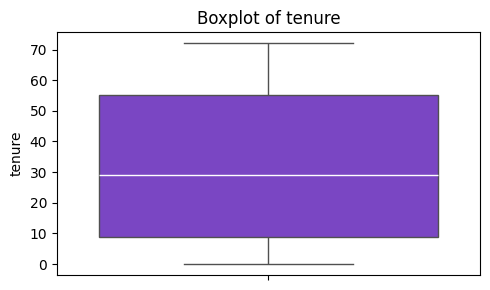

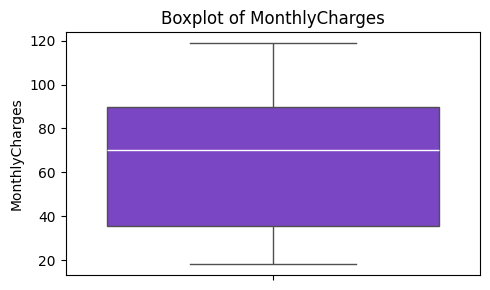

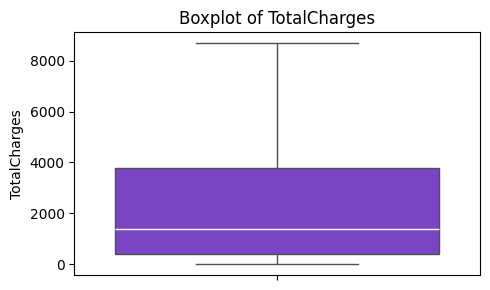

In [15]:
# Define the numerical columns to assess for potential outliers
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Generate boxplots for each numerical feature
for col in numerical_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(
        y=df[col],
        color="#7731d8",
        medianprops={"color":"white"}
    )

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

**Observations from Boxplots**

- The tenure variable shows a relatively balanced distribution with no substantial outlier behaviour.

- The MonthlyCharges and TotalCharges variables contain a small number of observations beyond the boxplot whiskers. These represent statistically identified outliers based on the IQR rule; however, they are consistent with genuine customer billing patterns rather than data quality issues.

- Although these observations fall outside the statistical IQR boundaries, they represent valid customer billing behaviour rather than data quality errors. Removing them would discard genuine business information and may reduce the model's ability to learn meaningful spending patterns. Therefore, no outlier treatment was applied at this stage.

#### 4.4.2 Using IQR

In [16]:
# Calculate the number of outliers in each numerical feature using the IQR method

outlier_counts = []

for col in numerical_cols:

    # Compute the first and third quartiles
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    iqr = q3 - q1

    # Define the lower and upper IQR bounds
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Count observations lying outside the IQR bounds
    outlier_count = (
        ((df[col] < lower_bound) | (df[col] > upper_bound))
        .sum()
    )

    # Store the results
    outlier_counts.append({
        "Feature": col,
        "Outlier Count": outlier_count
    })


# Display the outlier summary
outlier_summary = pd.DataFrame(outlier_counts)

display(outlier_summary)

,Feature,Outlier Count
0,tenure,0
1,MonthlyCharges,0
2,TotalCharges,0


**Conclusion on Outlier Assessment**

Both the boxplot visualisations and the Interquartile Range (IQR) analysis consistently identified a small number of statistical outliers in the `MonthlyCharges` and `TotalCharges` variables, while `tenure` exhibited no significant outlier behaviour.

As these observations represent legitimate customer records rather than data quality issues, no outlier treatment was performed. All observations were therefore retained for the subsequent exploratory analysis and predictive modelling stages.

### 4.5 Data Cleaning Summary

The following preprocessing steps were completed before exploratory analysis and predictive modelling:

- Verified that the dataset contained no duplicate records.
- Converted the `TotalCharges` column from `object` to `float64`.
- Identified and imputed 11 missing values in `TotalCharges` using a business-rule-based approach.
- Assessed numerical variables for potential outliers using boxplots and the IQR method.
- No duplicate records or outlier treatment were required.

---
The resulting dataset is internally consistent, free from duplicate records and missing values and suitable for feature engineering, exploratory analysis and predictive modelling.

### 4.6 Modelling Dataset Preparation

**Purpose**

- The cleaned dataset is copied to create a dedicated modelling dataset (df_model).

- This preserves the original preprocessed dataset while providing a separate working copy for feature engineering and model-specific transformations.

- The TenureCohort feature is created at this stage because it is required for the customer lifecycle analyses presented in section 5 (EDA). The remaining engineered features are introduced, implemented and evaluated in section 6.


In [17]:
# Create a separate dataset for feature engineering and modelling
df_model = df.copy()

# Create the Tenure Cohort feature for downstream analysis
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = [
    "New",
    "Developing",
    "Established",
    "Loyal"
]

df_model["TenureCohort"] = pd.cut(
    df_model["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Display the shape of the modelling dataset
print("Modelling Dataset Shape:", df_model.shape)

Modelling Dataset Shape: (7043, 22)


**Note:**

- A separate modelling dataset (`df_model`) has been created from the cleaned dataset.

- All subsequent feature engineering and machine learning steps will be performed using this dataset, ensuring that the original cleaned dataset remains unchanged.

## 5. Exploratory Data Analysis (EDA)

**Purpose**

The objective of Exploratory Data Analysis (EDA) is

1. To understand customer characteristics
2. Identify patterns associated with churn behaviour
3. Uncover relationships between variables that may influence customer retention

### 5.1 Target Variable Distribution

**Purpose**

Before analyzing predictor variables, it is important to understand the distribution of the target variable (Churn) and determine whether class imbalance exists.

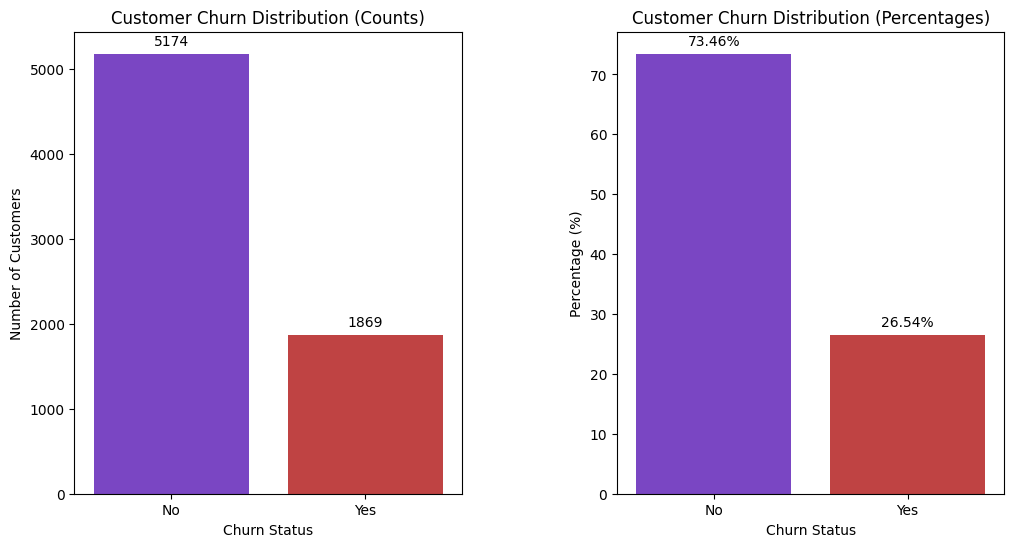

In [18]:
# Define custom color palette
palette = {
    "No": "#7731d8",   # Purple
    "Yes": "#d32f2f"   # Red
}

# Calculate the number of customers in each churn category
churn_counts = df_model["Churn"].value_counts()

# Calculate the percentage distribution of each churn category
churn_percentages = (
    df_model["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

# Create a figure containing the count and percentage distributions
plt.figure(figsize=(12, 6))

# Plot 1: Customer churn distribution (counts)
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    x="Churn",
    data=df_model,
    hue="Churn",
    palette=palette,
    legend=False
)

plt.title("Customer Churn Distribution (Counts)")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Display the count above each bar
for bar in ax1.patches:
    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )

# Plot 2: Customer churn distribution (percentages)
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    x=churn_percentages.index,
    y=churn_percentages.values,
    hue=churn_percentages.index,
    palette=palette,
    legend=False
)

plt.title("Customer Churn Distribution (Percentages)")
plt.xlabel("Churn Status")
plt.ylabel("Percentage (%)")

# Display the percentage above each bar
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():.2f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )

# Adjust spacing between the two plots manually
plt.subplots_adjust(wspace=0.4)

# Display the visualisations
plt.show()

**Business Observations on Customer Churn Distribution:**

- The distribution shows a clear **class imbalance**, with approximately **73.46% of customers not churning** (5174 customers) and **26.54% of customers churning** (1869 customers).

- From a business perspective, a churn rate of over 26% is significant and indicates a **substantial loss of revenue potential** and customer base. This highlights an urgent need for proactive customer retention strategies.

- This imbalance also implies that when building predictive models, **accuracy alone may be a misleading metric**. Metrics like precision, recall, F1-score, and AUC will be more appropriate to evaluate model performance, especially in correctly identifying the minority class (churning customers) which is of primary business interest.

### 5.2 Numerical Feature Analysis

#### 5.2.1 Tenure Distribution

- Customer tenure represents the duration of a customer's relationship with the telecom company.

- Understanding tenure distribution helps identify customer lifecycle patterns.

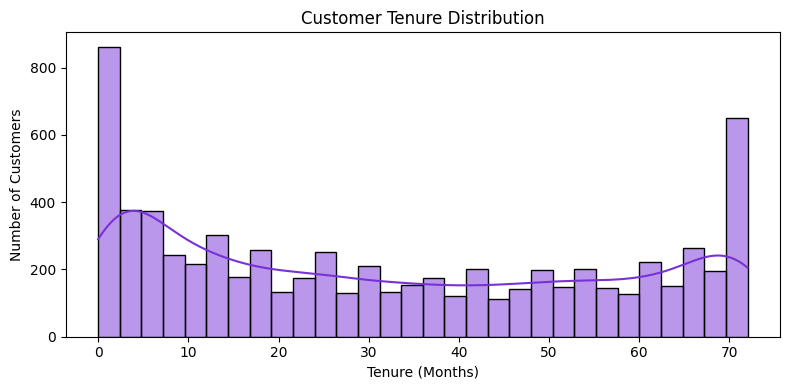

In [19]:
# Plot the distribution of customer tenure
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_model,
    x="tenure",
    bins=30,
    kde=True,
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

# Adjust spacing
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Customer Tenure Distribution:**

- The tenure distribution appears **bimodal**, indicating two dominant customer groups.

- A large proportion of customers have a tenure of **less than 5 months**, suggesting that customer attrition is relatively high during the early stages of the customer lifecycle.

- Another concentration of customers is observed between **65 and 72 months**, indicating a substantial base of long-term, loyal customers.

- Comparatively fewer customers fall within the intermediate tenure range, suggesting that customers tend to either leave early or remain with the company for an extended period.

- This bimodal pattern implies that understanding the factors contributing to early churn versus long-term loyalty will be crucial for targeted retention strategies.

#### 5.2.2 Monthly Charges Distribution

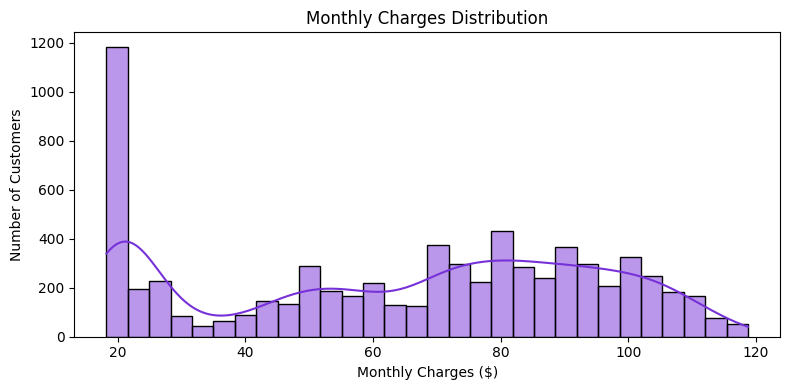

In [20]:
# Plot the distribution of monthly charges
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_model,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

# Adjust spacing
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Monthly Charges Distribution**

- The distribution of monthly charges is **right-skewed**, with a large concentration of customers paying relatively low monthly charges (around \$20).

- Customer charges are spread across a wide range of values, with most customers paying between **\$20 and \$110** per month.

- The broader distribution at higher monthly charges suggests that customers subscribe to different service plans and add-on combinations, resulting in varying monthly bills.

- The absence of extreme spikes or isolated values indicates that monthly charges are reasonably distributed across the customer base.

- Since monthly charges directly reflect the cost of subscribed services, this feature may influence customer satisfaction and affordability, making it a potentially important predictor of customer churn.

#### 5.2.3 Total Charges Distribution

`TotalCharges` represents cumulative customer revenue.

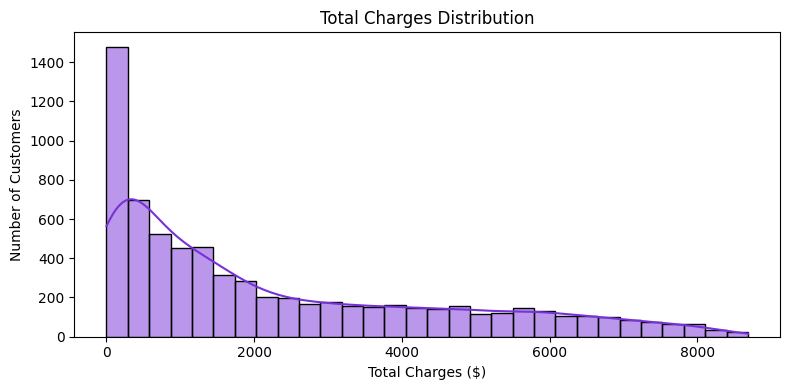

In [21]:
# Plot the distribution of total charges

# Set the figure size for the plot
plt.figure(figsize=(8, 4))

# Create a histogram with a Kernel Density Estimate (KDE) for TotalCharges
# bins=30 defines the number of bars, and color sets the bar color
sns.histplot(
    data=df_model,
    x="TotalCharges",
    bins=30,
    kde=True,
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges ($)")
plt.ylabel("Number of Customers")

# Adjust spacing
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Total Charges Distribution:**

1. The distribution of `TotalCharges` is **strongly right-skewed**, with most customers concentrated at lower cumulative charge values.

2. A prominent peak is observed near 0, indicating that many customers have accumulated relatively low total charges. This is expected because new customers and customers with short tenures have had less time to accumulate charges.

3. The frequency of customers decreases steadily as TotalCharges increases, producing a long right tail. Only a relatively small proportion of customers have accumulated very high lifetime charges.

4. This distribution is consistent with the business definition of TotalCharges, which is a cumulative measure primarily driven by customer tenure and MonthlyCharges.

5. Customers who remain with the company for longer periods naturally accumulate higher total charges.

---
From a business perspective, the distribution suggests that long-term customers contribute a disproportionately large share of cumulative revenue. Consequently, retaining existing customers is likely to generate substantially greater lifetime value than continuously acquiring new customers, reinforcing the importance of effective customer retention strategies.

### 5.3 Categorical Feature Analysis

#### 5.3.1 Contract Type Distribution

Contract structure is expected to influence churn behaviour.

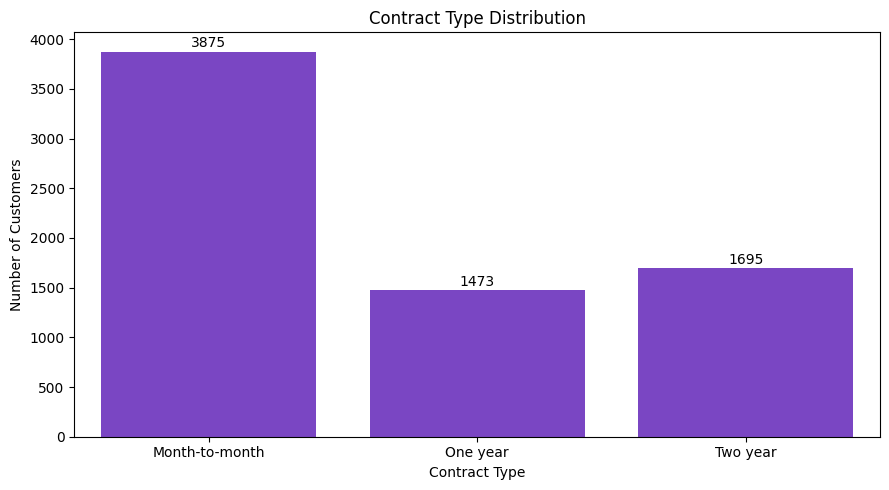

In [22]:
# Plot the distribution of customer contract types

# Set the figure size for the plot
plt.figure(figsize=(9, 5))

# Create a count plot for the 'Contract' column
ax = sns.countplot(
    data=df_model,
    x="Contract",
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Display the count above each bar
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,1),
        textcoords="offset points"
    )

# Adjust spacing
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Contract Type Distribution**

- **Month-to-month** is the most common contract type, accounting for **3,875 customers** (approximately **55%** of the customer base).

- **Two-year contracts** are the second most common, with **1,695 customers**, followed by **One-year contracts** with **1,473 customers**.

- The predominance of month-to-month contracts indicates that a large proportion of customers are not committed to long-term agreements and therefore have greater flexibility to discontinue the service.

- In contrast, customers on one-year and two-year contracts represent a smaller but more committed segment of the customer base.

- Although this distribution does not directly indicate which contract type experiences higher churn, contract duration is expected to be an important predictor of customer churn and will be examined further through bivariate analysis with the target variable.

#### 5.3.2 Internet Service Distribution

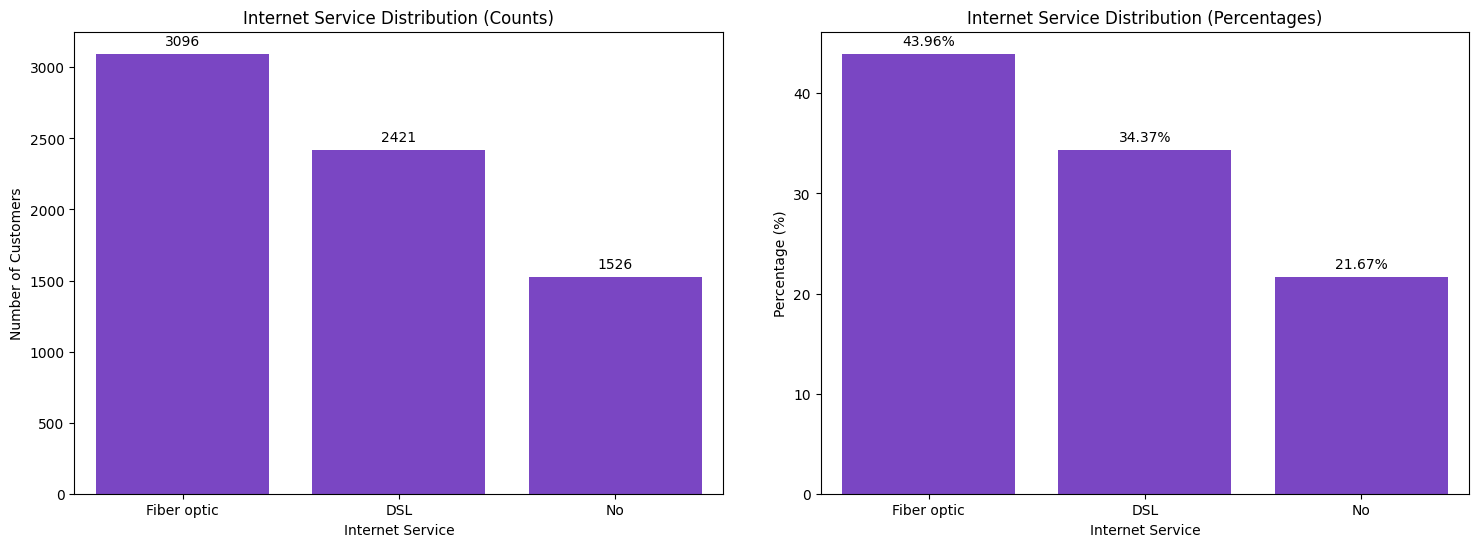

In [23]:
# Calculate the number and percentage of customers by Internet Service type
internet_service_counts = df_model["InternetService"].value_counts()
internet_service_percentages = (df_model["InternetService"].value_counts(normalize=True) * 100)

# Preserve the same category order across both plots
order = internet_service_counts.index

# Create side-by-side visualisations
plt.figure(figsize=(18, 6))


# Plot the number of customers in each Internet Service category
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="InternetService",
    order=order,
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Internet Service Distribution (Counts)")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

# Display the count above each bar
for bar in ax1.patches:
    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )


# Plot the percentage distribution of Internet Service categories
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    x=internet_service_percentages.index,
    y=internet_service_percentages.values,
    order=order,
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Internet Service Distribution (Percentages)")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")

# Display the percentage above each bar
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():.2f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )

# Adjust spacing between the two plots
plt.subplots_adjust(wspace=0.15)

# Display the plots
plt.show()

**Observations on Internet Service Distribution**

- **Fiber optic** is the most widely used internet service, with **3,096 customers (43.96%)**, making it the largest customer segment.

- **DSL** is the second most common service, used by **2,421 customers (34.37%)**, while **1,526 customers (21.67%)** do not subscribe to an internet service.

- Overall, **78.33% of customers subscribe to an internet service**, indicating that internet connectivity is a core component of the company's service offerings.

- The higher adoption of Fiber optic services suggests a strong customer preference for high-speed internet plans and premium service packages.

- While this analysis describes the distribution of internet service types, it does not indicate whether a particular service type is associated with customer churn. This relationship will be examined further through bivariate analysis with the target variable.

#### 5.3.3 Payment Method Distribution

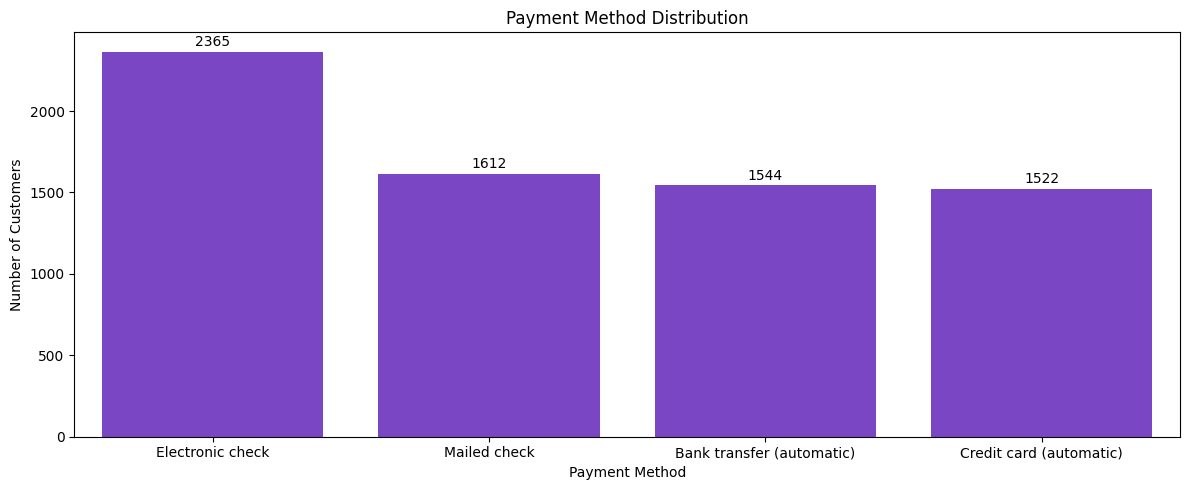

In [24]:
# Plot the distribution of customer payment methods
plt.figure(figsize=(12, 5))

ax = sns.countplot(
    data=df_model,
    x="PaymentMethod",
    color="#7731d8"
)

# Add chart title and axis labels
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

# Display the count above each bar
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 2),
        textcoords="offset points"
    )

# Adjust spacing
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Payment Method Distribution:**

- **Electronic check** is the most frequently used payment method, with **2,365 customers**, accounting for approximately one-third of the customer base.

- The remaining payment methods are distributed fairly evenly, with **Mailed check (1,612 customers)**, **Bank transfer (automatic) (1,544 customers)**, and **Credit card (automatic) (1,522 customers)** showing similar levels of adoption.

- The relatively balanced distribution among the three non-electronic payment methods suggests that customers use a variety of payment options, whereas electronic checks appear to be the dominant preference.

- Understanding whether payment method influences customer churn requires further analysis with the target variable. This relationship will be examined in the subsequent bivariate analysis.

### 5.4 Customer Demographics & Churn

Customer demographic characteristics may influence customer retention behaviour. This section examines the relationship between key demographic attributes and churn status to identify customer segments that may be more susceptible to leaving the telecom service.

#### 5.4.1 Senior Citizen vs Churn

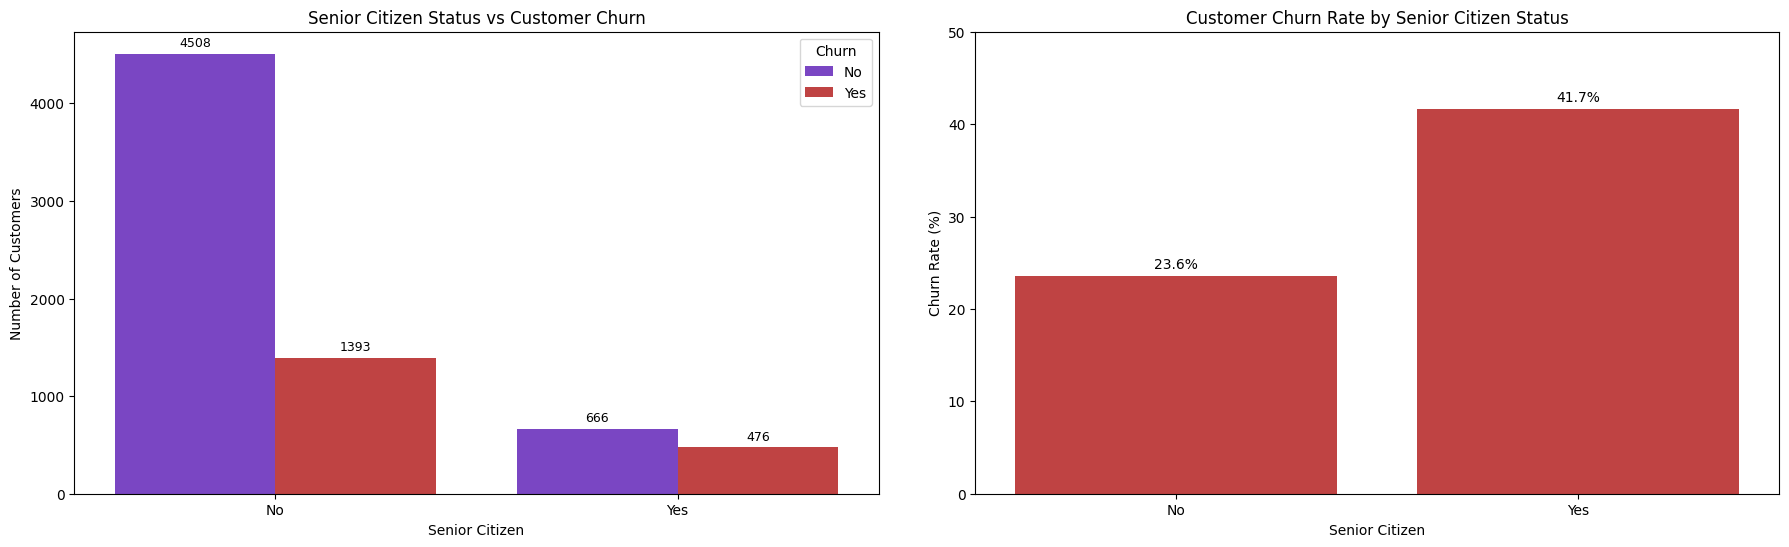

In [25]:
# Calculate the churn rate (%) for each Senior Citizen category
senior_churn_rate = (
    df_model
    .groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

# Replace numeric values with readable labels
senior_churn_rate["SeniorCitizen"] = senior_churn_rate["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))



# Plot 1: Customer Counts by Senior Citizen Status & Churn
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="SeniorCitizen",
    hue="Churn",
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add chart title and axis labels
plt.title("Senior Citizen Status vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

# Replace numeric labels
plt.xticks(
    ticks=[0, 1],
    labels=["No", "Yes"]
)

# Add legend
plt.legend(title="Churn")

# Display counts above each bar
for bar in ax1.patches:

    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )


# Plot 2: Churn Rate by Senior Citizen Status
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=senior_churn_rate,
    x="SeniorCitizen",
    y="ChurnRate",
    color="#d32f2f"
)

# Add chart title and axis labels
plt.title("Customer Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

# Display percentage above each bar
for bar in ax2.patches:

    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )
plt.ylim(0, 50)

# Adjust spacing
plt.subplots_adjust(wspace=0.12)

# Display the plots
plt.show()

**Observations on Senior Citizen Status vs Customer Churn**

- The majority of customers are **not senior citizens**, comprising **5,901 customers** (4,508 retained and 1,393 churned).

- The senior citizen segment is considerably smaller, with **1,142 customers** (666 retained and 476 churned).

- Despite representing a smaller proportion of the customer base, **senior citizens exhibit a substantially higher churn rate (41.7%)** compared with **non-senior citizens (23.6%)**.

- This indicates that senior citizen customers are considerably more likely to discontinue the telecom service, making them an important segment for targeted retention initiatives.

- These findings suggest that demographic characteristics, particularly senior citizen status, may influence customer retention behaviour and should be considered during predictive modelling.

#### 5.4.2 Gender vs Churn

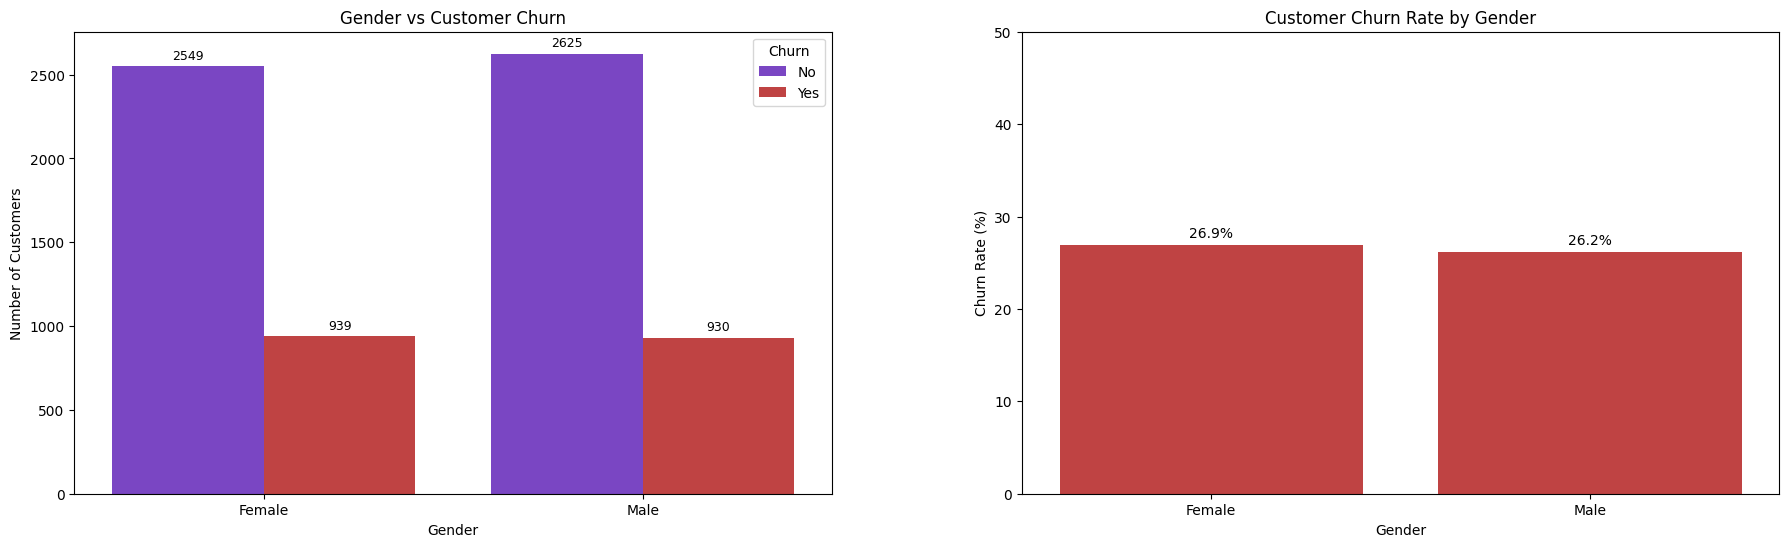

In [26]:
# Calculate the churn rate (%) for each gender
gender_churn_rate = (
    df_model
    .groupby("gender")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))


# Plot 1: Customer Counts by Gender & Churn
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="gender",
    hue="Churn",
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add chart title and axis labels
plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Add legend
plt.legend(title="Churn")

# Display counts above each bar
for bar in ax1.patches:

    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )


# Plot 2: Customer Churn Rate by Gender
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=gender_churn_rate,
    x="gender",
    y="ChurnRate",
    color="#d32f2f"
)

# Add chart title and axis labels
plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

# Set y-axis limit for consistency
ax2.set_ylim(0, 50)

# Display percentage above each bar
for bar in ax2.patches:

    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Adjust spacing between plots
plt.subplots_adjust(wspace=0.25)

# Display the plots
plt.show()

**Observations on Gender vs Customer Churn**

- The customer base is almost evenly distributed across gender, with **3,488 female customers** and **3,555 male customers**.

- The distribution of retained and churned customers is also similar for both genders, indicating no substantial difference in customer composition.

- The normalized churn rates further confirm this observation. **Female customers exhibit a churn rate of 26.9%**, while **male customers exhibit a churn rate of 26.2%**.

- The difference in churn rate between genders is less than one percentage point, suggesting that **gender is not a strong differentiating factor for customer churn** in this dataset.

- These findings indicate that customer retention strategies are unlikely to benefit from gender-specific targeting and should instead focus on behavioural and service-related characteristics.

#### 5.4.3 Partner vs Churn

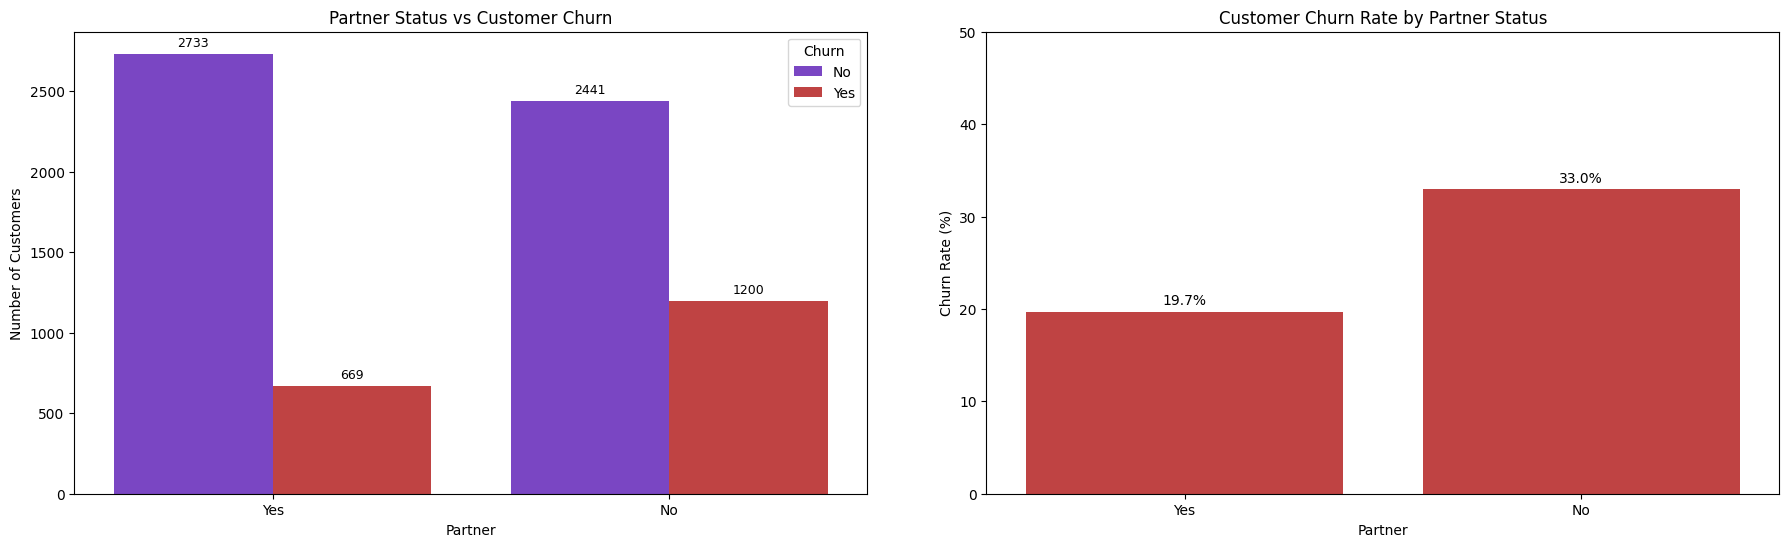

In [27]:
# Calculate the churn rate (%) for each Partner category
partner_churn_rate = (
    df_model
    .groupby("Partner")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))

partner_order = ["Yes", "No"]

# Plot 1: Customer Counts by Partner Status & Churn
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="Partner",
    hue="Churn",
    order=partner_order,
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add chart title and axis labels
plt.title("Partner Status vs Customer Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

# Add legend
plt.legend(title="Churn")

# Display counts above each bar
for bar in ax1.patches:

    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )


# Plot 2: Customer Churn Rate by Partner Status
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=partner_churn_rate,
    x="Partner",
    y="ChurnRate",
    order=partner_order,
    color="#d32f2f"
)

# Add chart title and axis labels
plt.title("Customer Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

# Keep the same scale across churn-rate charts
ax2.set_ylim(0, 50)

# Display percentage above each bar
for bar in ax2.patches:

    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Adjust spacing
plt.subplots_adjust(wspace=0.15)

# Display the plots
plt.show()

**Observations on Partner Status vs Customer Churn**

- Customers with partners constitute a slightly larger segment of the customer base, with **3,402 customers** (2,733 retained and 669 churned), compared to **3,641 customers** without partners (2,441 retained and 1,200 churned).

- Customers **without a partner** exhibit a substantially higher churn rate (**33.0%**) than customers **with a partner** (**19.7%**).

- The difference of more than **13 percentage points** suggests that customers without partners are considerably more likely to discontinue the telecom service.

- This pattern indicates that partner status may be associated with customer retention behaviour, making customers without partners an important segment for proactive retention initiatives.

- The findings also suggest that partner status could provide useful predictive information for the churn classification model.

#### 5.4.4 Dependents vs Churn

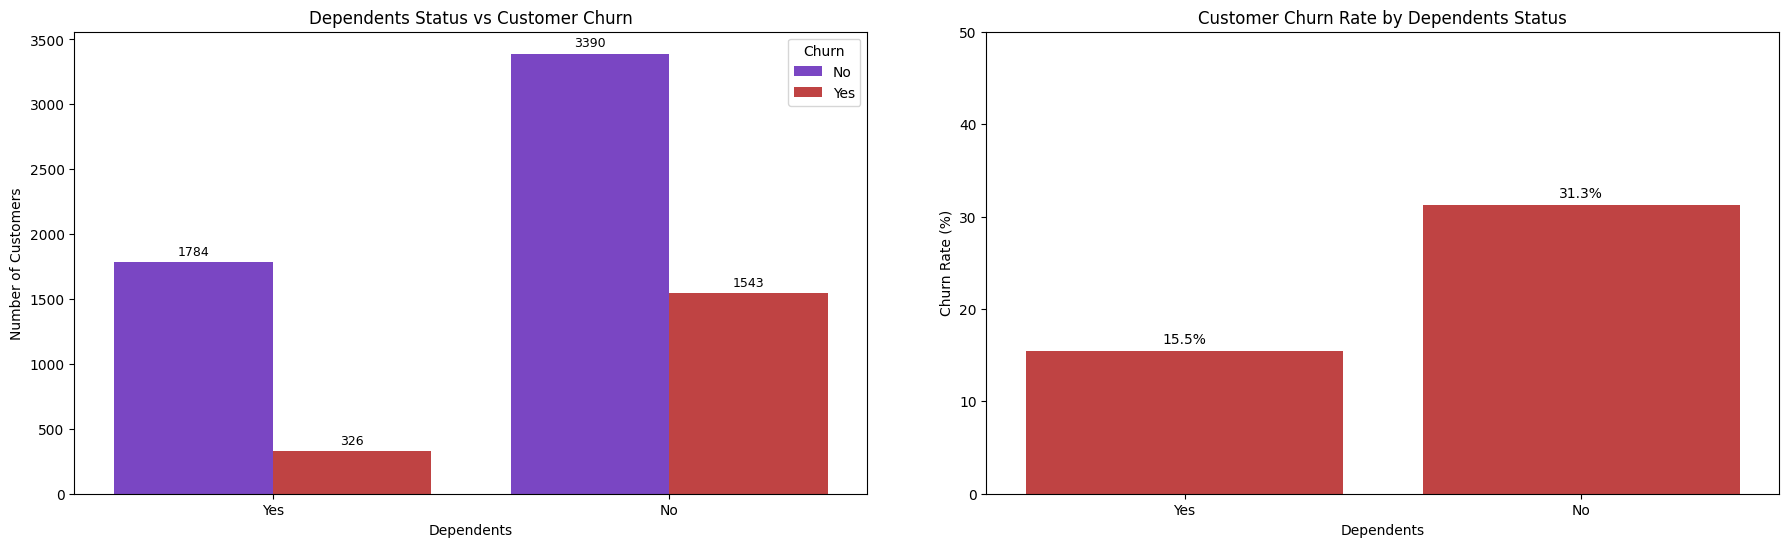

In [28]:
# Define the category order for consistent plotting
dependents_order = ["Yes", "No"]

# Calculate the churn rate (%) for each Dependents category
dependents_churn_rate = (
    df_model
    .groupby("Dependents")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))


# Plot 1: Customer Counts by Dependents Status & Churn
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="Dependents",
    hue="Churn",
    order=dependents_order,
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add chart title and axis labels
plt.title("Dependents Status vs Customer Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

# Add legend
plt.legend(title="Churn")

# Display counts above each bar
for bar in ax1.patches:

    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Plot 2: Customer Churn Rate by Dependents Status
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=dependents_churn_rate,
    x="Dependents",
    y="ChurnRate",
    order=dependents_order,
    color="#d32f2f"
)

# Add chart title and axis labels
plt.title("Customer Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

# Keep the same y-axis scale across churn-rate charts
ax2.set_ylim(0, 50)

# Display percentage above each bar
for bar in ax2.patches:

    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Adjust spacing
plt.subplots_adjust(wspace=0.15)

# Display the plots
plt.show()

**Observations on Dependents Status vs Customer Churn**

- Customers without dependents form the larger segment of the customer base, comprising **4,933 customers** (3,390 retained and 1,543 churned), compared with **2,110 customers** who have dependents (1,784 retained and 326 churned).

- Customers **without dependents** exhibit a substantially higher churn rate (**31.3%**) than customers **with dependents** (**15.5%**).

- The churn rate among customers without dependents is approximately **twice** that of customers with dependents, indicating a strong association between dependent status and customer retention.

- This finding suggests that customers without dependents represent a higher-risk segment and may benefit from targeted retention strategies.

- The clear separation in churn rates also indicates that **Dependents** is likely to be a valuable predictive feature for the churn classification model.

### 5.5 Service Adoption & Churn

Telecom providers offer several value-added services, such as Online Security, Online Backup, Device Protection and Technical Support, to enhance the customer experience.

This section investigates whether the adoption of these services is associated with customer churn and identifies services that may contribute to improved customer retention.

#### 5.5.1 Value-added services vs Churn

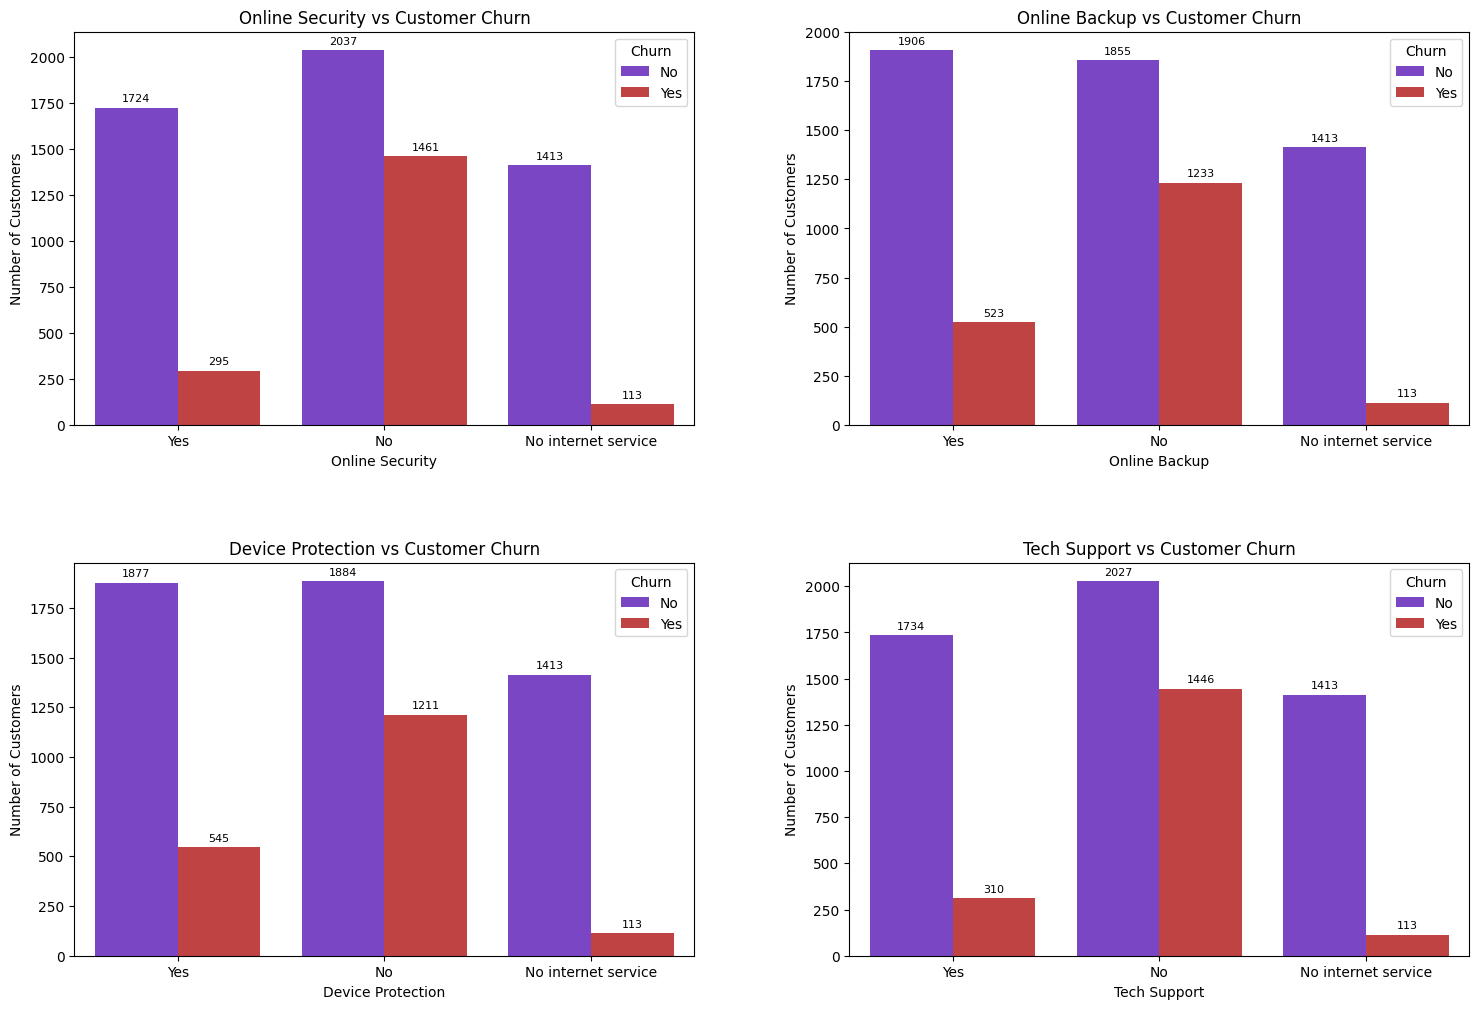

In [29]:
# Define the value-added services to analyse
services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

# Define a consistent category order
service_order = [
    "Yes",
    "No",
    "No internet service"
]

# Create a mapping for cleaner subplot titles
service_titles = {
    "OnlineSecurity": "Online Security",
    "OnlineBackup": "Online Backup",
    "DeviceProtection": "Device Protection",
    "TechSupport": "Tech Support"
}

# Create a 2 × 2 grid of subplots
plt.figure(figsize=(18, 12))

# Generate one subplot for each value-added service
for i, service in enumerate(services, start=1):

    plt.subplot(2, 2, i)

    ax = sns.countplot(
        data=df_model,
        x=service,
        hue="Churn",
        order=service_order,
        palette={
            "No": "#7731d8",
            "Yes": "#d32f2f"
        }
    )

    # Add title and axis labels
    plt.title(f"{service_titles[service]} vs Customer Churn")
    plt.xlabel(service_titles[service])
    plt.ylabel("Number of Customers")

    # Display count labels above each bar
    for bar in ax.patches:

        if bar.get_height() == 0:
            continue

        ax.annotate(
            f"{int(bar.get_height())}",
            (
                bar.get_x() + bar.get_width() / 2,
                bar.get_height()
            ),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points"
        )

    # Add legend
    plt.legend(title="Churn")

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.25,hspace=0.35)

# Display the visualisations
plt.show()

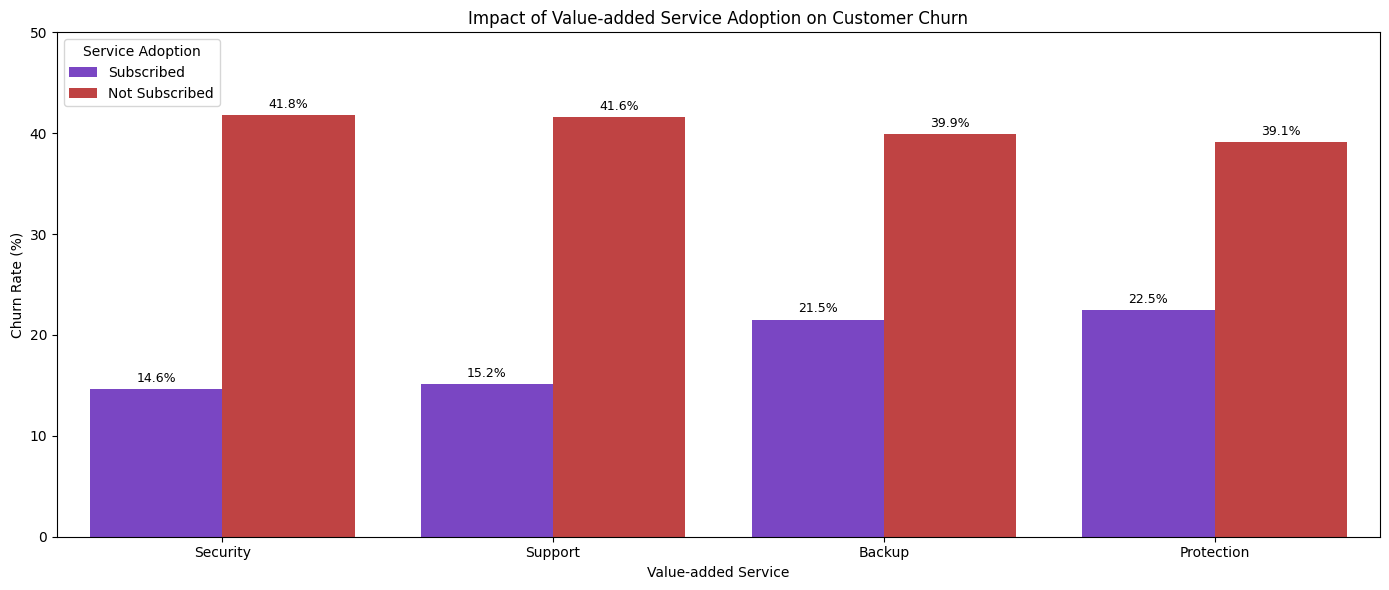

In [30]:
# Define the value-added services to analyse
services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

# Create an empty list to store churn-rate results
churn_rate_summary = []

# Calculate churn rates for customers with and without each service
for service in services:

    # Exclude customers with no internet service
    churn_rates = (
        df_model[df_model[service] != "No internet service"]
        .groupby(service)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    churn_rate_summary.append({
        "Service": service,
        "Subscribed": churn_rates["Yes"],
        "Not Subscribed": churn_rates["No"]
    })

# Convert results into a DataFrame
churn_rate_df = pd.DataFrame(churn_rate_summary)

# Replace service names with shorter, presentation-friendly labels
churn_rate_df["Service"] = churn_rate_df["Service"].replace({
    "OnlineSecurity": "Security",
    "OnlineBackup": "Backup",
    "DeviceProtection": "Protection",
    "TechSupport": "Support"
})

# Sort services by churn rate among subscribed customers
churn_rate_df = churn_rate_df.sort_values(
    by="Subscribed"
)

# Reshape the data for plotting
plot_df = churn_rate_df.melt(
    id_vars="Service",
    value_vars=[
        "Subscribed",
        "Not Subscribed"
    ],
    var_name="Service Adoption",
    value_name="Churn Rate"
)

# Create the grouped bar chart
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=plot_df,
    x="Service",
    y="Churn Rate",
    hue="Service Adoption",
    palette={
        "Subscribed": "#7731d8",
        "Not Subscribed": "#d32f2f"
    }
)

# Add chart title and axis labels
plt.title("Impact of Value-added Service Adoption on Customer Churn")
plt.xlabel("Value-added Service")
plt.ylabel("Churn Rate (%)")

# Keep a consistent y-axis across churn-rate charts
plt.ylim(0, 50)

# Display percentage labels above each bar
for bar in ax.patches:

    # Skip zero-height bars (prevents unwanted 0.0% labels)
    if bar.get_height() == 0:
        continue

    ax.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Add legend
plt.legend(
    title="Service Adoption",
    loc="upper left"
)

# Improve spacing
plt.tight_layout()

# Display the plot
plt.show()

**Interpretation**

1. Online Security shows the strongest relationship with customer retention. Customers who subscribe to Online Security have a churn rate of only 14.6%, compared with 41.8% among customers who do not subscribe.

2. Technical Support demonstrates a similarly strong pattern. Customers with Technical Support experience a churn rate of 15.2%, whereas customers without the service churn at 41.6%.

3. Online Backup is also associated with improved retention. Customers using Online Backup have a churn rate of 21.5%, compared with 39.9% for customers who do not use the service.

4. Device Protection follows the same trend, although the reduction is comparatively smaller. Customers with Device Protection have a churn rate of 22.5%, versus 39.1% for those without the service.
---
Customers with No Internet Service consistently exhibit very low churn counts across all four service categories. This is expected because these customers are not eligible to subscribe to internet-dependent value-added services and therefore represent a distinct customer segment.

#### 5.5.2 Internet Service vs Churn

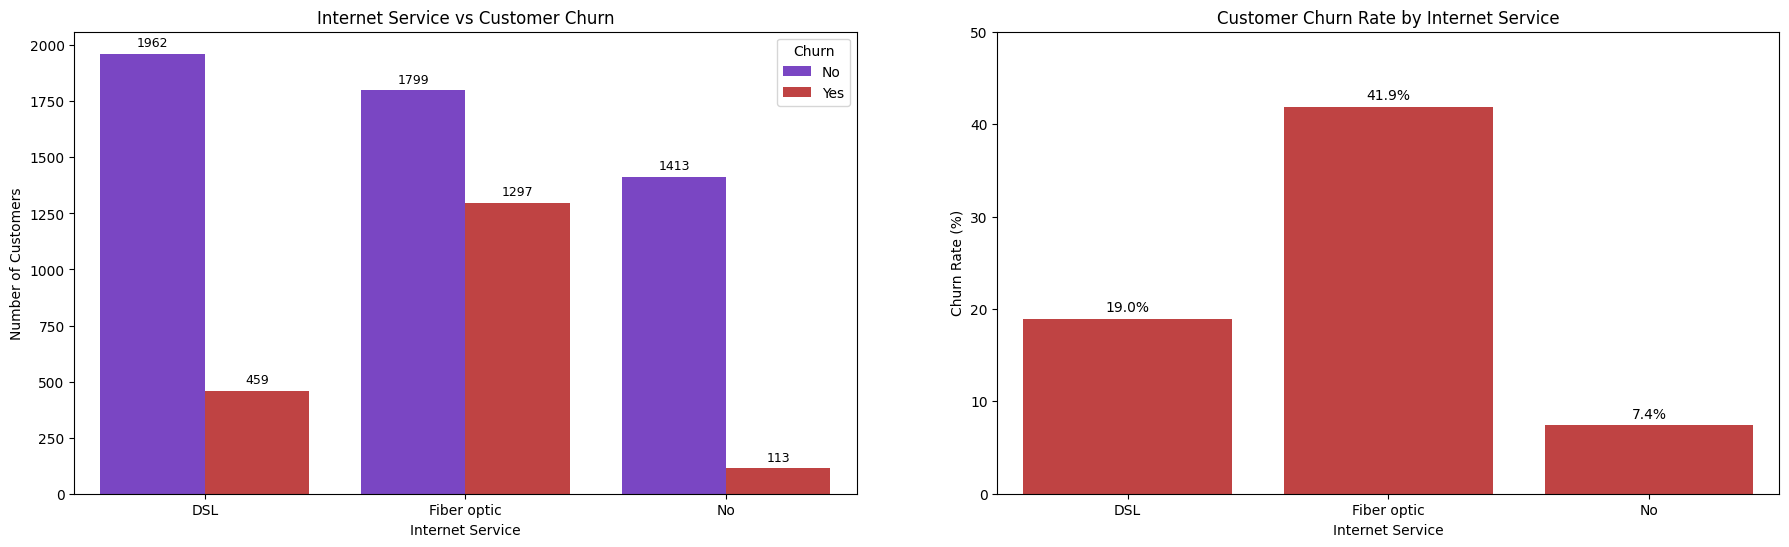

In [31]:
# Calculate churn rate by Internet Service
internet_churn_rate = (
    df_model
    .groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

# Define category order for consistency
service_order = ["DSL", "Fiber optic", "No"]

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))

# Plot 1: Customer counts by Internet Service
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="InternetService",
    hue="Churn",
    order=service_order,
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

# Display counts above bars
for bar in ax1.patches:
    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Plot 2: Normalized churn rate

plt.subplot(1, 2, 2)

internet_churn_rate["InternetService"] = pd.Categorical(
    internet_churn_rate["InternetService"],
    categories=service_order,
    ordered=True
)

internet_churn_rate = internet_churn_rate.sort_values("InternetService")

ax2 = sns.barplot(
    data=internet_churn_rate,
    x="InternetService",
    y="ChurnRate",
    color="#d32f2f"
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

# Keep the same y-axis scale across churn-rate charts
ax2.set_ylim(0, 50)

# Display percentages above bars
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Adjust spacing
plt.subplots_adjust(wspace=0.18)

# Display plots
plt.show()

**Observations on Internet Service vs Customer Churn**

1. **Fiber optic customers exhibit the highest churn rate (41.9%)**, more than double that of DSL customers (19.0%). This indicates that customers using Fiber optic services are substantially more likely to leave the telecom provider.

2. DSL customers demonstrate considerably better retention, with a churn rate of only 19.0%, suggesting greater customer satisfaction or lower switching propensity.

3. Customers with **No Internet Service** show the **lowest churn rate** (7.4%), indicating that this customer segment is relatively stable and less likely to discontinue their telecom service.

4. Although Fiber optic has a customer base comparable to DSL, it contributes disproportionately to overall customer churn because of its substantially higher churn rate.

---
**Business Insight**

The normalized churn-rate analysis indicates that **Internet Service type is one of the strongest predictors of customer churn**.

In particular, Fiber optic customers represent the highest-risk segment and should be prioritized for retention initiatives. Possible drivers such as pricing, service quality, network reliability, or customer expectations warrant further investigation to understand the causes of the elevated churn.

### 5.6 Billing & Pricing Behaviour

#### 5.6.1 Contract Type vs Churn

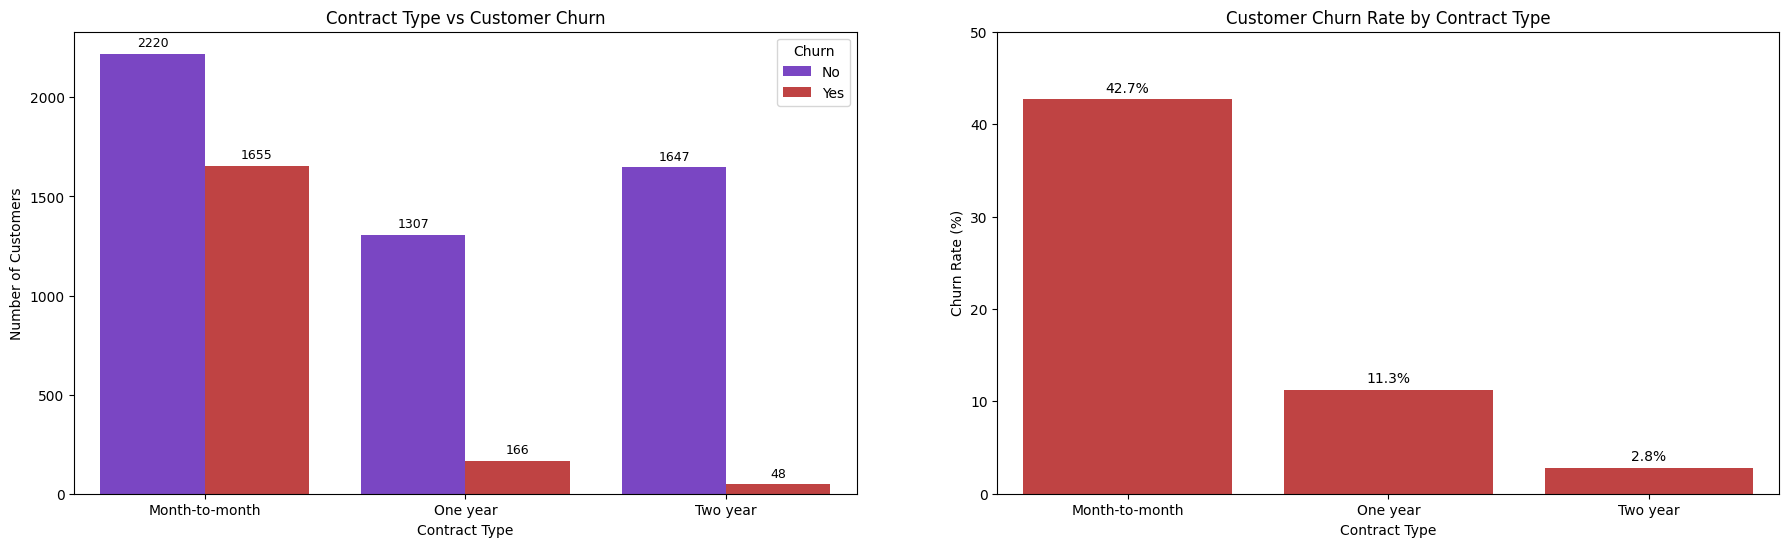

In [32]:
# Create side-by-side visualisations
plt.figure(figsize=(22, 6))

# Plot 1: Contract Type vs Churn (Counts)
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="Contract",
    hue="Churn",
    order=["Month-to-month", "One year", "Two year"],
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add title and axis labels
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Add count labels
for bar in ax1.patches:
    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.legend(title="Churn")


# Plot 2: Contract-wise Churn Rate
contract_churn = (
    df_model
    .groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(["Month-to-month", "One year", "Two year"])
    .reset_index(name="ChurnRate")
)

plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=contract_churn,
    x="Contract",
    y="ChurnRate",
    color="#d32f2f"
)

# Add title and axis labels
plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

# Add percentage labels
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Keep the same y-axis scale across churn-rate charts
ax2.set_ylim(0, 50)

# Keep consistent spacing with previous sections
plt.subplots_adjust(wspace=0.18)

plt.show()

**Observations on Churn by Contract Type:**

1. **Month-to-month** customers exhibit the highest churn rate (42.7%), indicating that customers without long-term contractual commitment are substantially more likely to leave.

2. Customers on one-year contracts have a much lower churn rate (11.3%), suggesting that contractual commitment improves customer retention.

3. Two-year contracts show the lowest churn rate (2.8%), demonstrating the strongest customer loyalty among all contract types.
---
Although **month-to-month** customers constitute the largest customer segment, they also account for the overwhelming majority of churn cases, making them the **highest-risk segment** for retention initiatives.

#### 5.6.2 Monthly Charges vs Churn

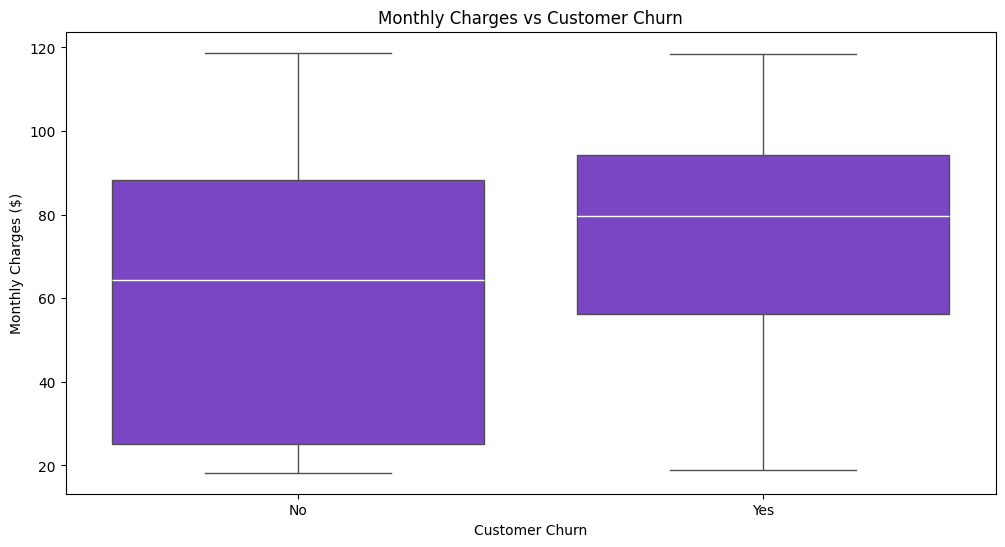

In [33]:
# Compare the distribution of Monthly Charges across churn categories

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a boxplot
sns.boxplot(
    data=df_model,
    x="Churn",
    y="MonthlyCharges",
    order=["No", "Yes"],
    color="#7731d8",
    medianprops={"color": "white"}
)

# Add title and axis labels
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges ($)")

# Display the plot
plt.show()

**Observations on Monthly Charges by Churn Status:**

1. Customers who **churn generally have higher monthly charges** than those who remain with the company. The median monthly charge for churned customers is noticeably higher.

2. The middle 50% (interquartile range) of monthly charges for churned customers is shifted towards higher values, indicating that customers paying relatively higher monthly fees are more likely to discontinue the service.
Customers who did not churn exhibit a wider spread of monthly charges, ranging from low-cost to premium plans, whereas churned customers are more concentrated in the medium-to-high monthly charge range.

3. Despite this overall trend, there is **considerable overlap** between the two distributions. This suggests that **MonthlyCharges alone is not sufficient to explain customer churn** and should be interpreted alongside other factors such as contract type, tenure and internet service, which were found to have stronger relationships with churn.
---
**Business Insight**

Higher monthly charges appear to be associated with an increased likelihood of customer churn. Customers paying premium monthly fees may have higher service expectations or may be more sensitive to perceived value, making them an important segment for targeted retention initiatives. However, pricing should not be viewed in isolation, as churn is influenced by multiple interacting customer and service characteristics.

#### 5.6.3 Payment Method vs Churn

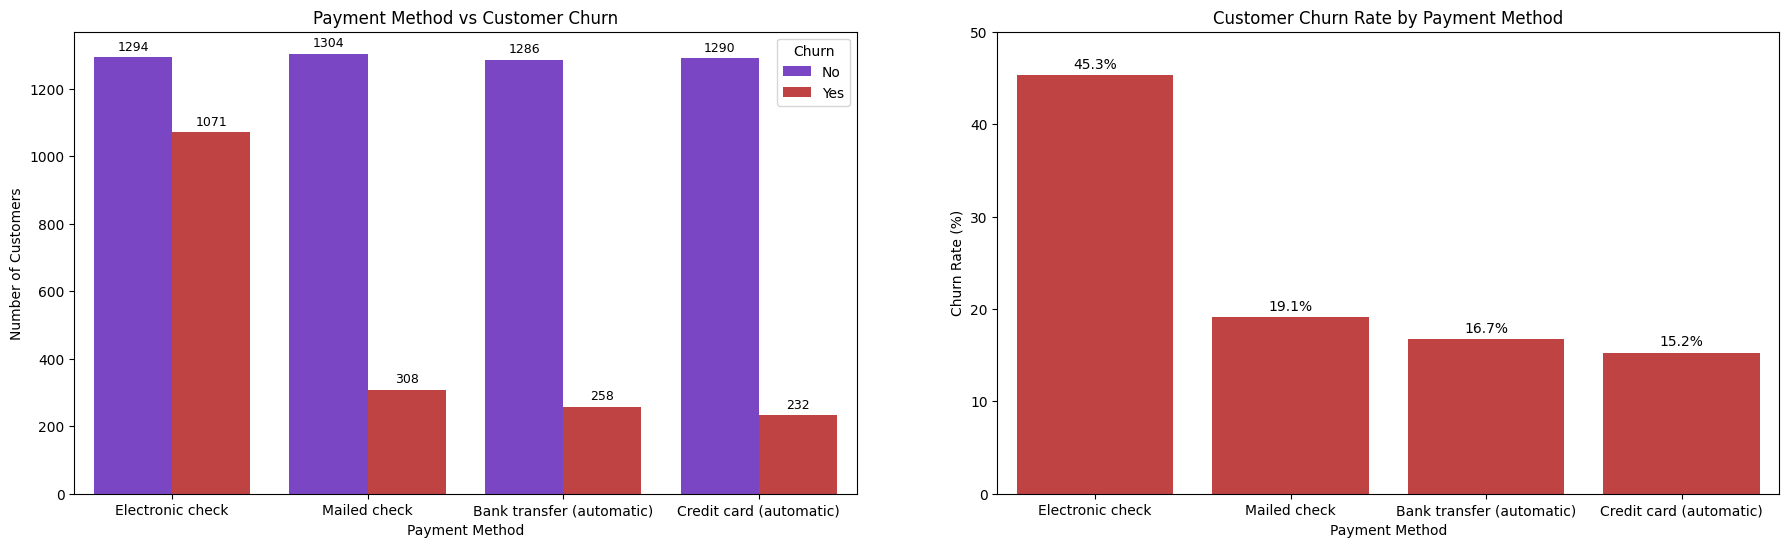

In [34]:
# Create side-by-side visualisations
plt.figure(figsize=(22, 6))

# Plot 1: Payment Method vs Customer Churn (Counts)

payment_order = [
    "Electronic check",
    "Mailed check",
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="PaymentMethod",
    hue="Churn",
    order=payment_order,
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add title and axis labels
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

# Display count labels
for bar in ax1.patches:

    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0,3),
        textcoords="offset points"
    )


plt.legend(title="Churn")


# Plot 2: Payment Method Churn Rate

payment_churn = (
    df_model
    .groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(payment_order)
    .reset_index(name="ChurnRate")
)

plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRate",
    color="#d32f2f"
)

# Add title and axis labels
plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 50)

# Display percentage labels
for bar in ax2.patches:

    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,3),
        textcoords="offset points"
    )

# Adjust spacing
plt.subplots_adjust(wspace=0.18)

plt.show()

**Observations on Payment Method vs Customer Churn:**

1. Customers using **Electronic Check** exhibit the **highest churn rate** (45.3%), making this the highest-risk payment segment despite having a customer base comparable to the other payment methods.

2. Customers using automatic payment methods demonstrate substantially lower churn rates, with Credit Card (automatic) showing the lowest churn (15.2%), followed by Bank Transfer (automatic) (16.7%).

3. Customers paying via Mailed Check have a moderate churn rate (19.1%), considerably lower than Electronic Check but higher than automatic payment methods.

Although the four payment methods have similar numbers of customers, their churn rates differ markedly, indicating that the method of payment is associated with customer retention behaviour.

---
**Business Insight**

The normalized churn-rate analysis suggests that **Payment Method is an important behavioural indicator of churn risk**.

Customers using Electronic Check are substantially more likely to leave the telecom provider than customers enrolled in automatic payment methods.

Encouraging customers to adopt automatic billing options may improve customer retention, although this relationship should be interpreted alongside other influential factors such as contract type, tenure and internet service.

#### 5.6.4 Paperless Billing vs Churn

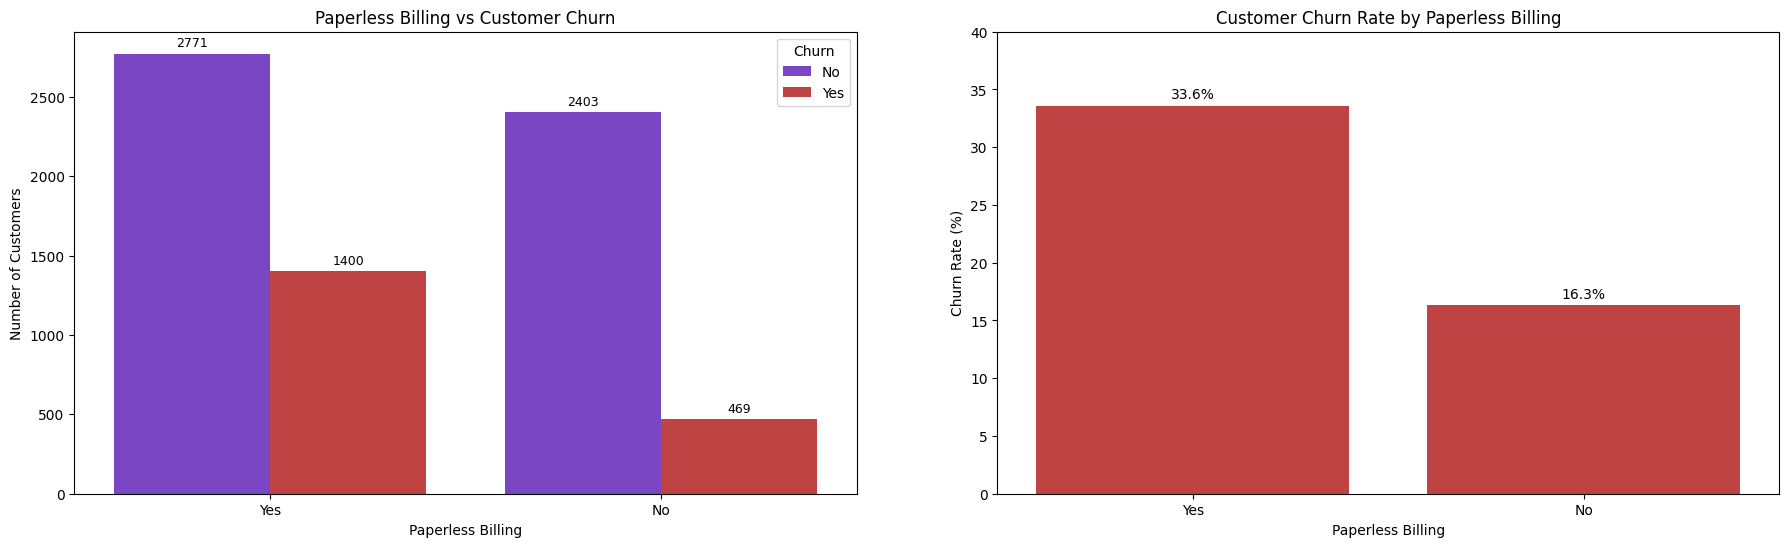

In [35]:
# Calculate churn rate by Paperless Billing status
paperless_churn_rate = (
    df_model
    .groupby("PaperlessBilling")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

billing_order = ["Yes", "No"]

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))

# Plot 1: Customer Counts
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="PaperlessBilling",
    hue="Churn",
    order=billing_order,
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

plt.title("Paperless Billing vs Customer Churn")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

# Display counts above bars
for bar in ax1.patches:
    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0,3),
        textcoords="offset points"
    )

# Plot 2: Churn Rate
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=paperless_churn_rate,
    x="PaperlessBilling",
    y="ChurnRate",
    order=billing_order,
    color="#d32f2f"
)


ax2.set_ylim(0, 40)

plt.title("Customer Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

# Display churn-rate labels
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,3),
        textcoords="offset points"
    )

plt.subplots_adjust(wspace=0.18)

plt.show()

**Observations on Paperless Billing and Payment Methods:**

1. Customers using **Paperless Billing** exhibit a **substantially higher churn rate** (33.6%) compared to customers receiving paper bills (16.3%).

2. Although customers with Paperless Billing represent a large portion of the customer base, they also account for a disproportionately higher number of churned customers.

3. The **churn rate for customers enrolled in Paperless Billing is more than double that of customers who do not use Paperless Billing**, indicating a strong association between paperless billing and customer churn.

4. While Paperless Billing itself is unlikely to directly cause churn, it may serve as a behavioural indicator. Customers opting for digital billing may also be more digitally engaged, more price-sensitive, or more likely to compare competing service providers, making them more susceptible to switching.

---
This relationship suggests that customers enrolled in Paperless Billing may represent an important segment for targeted retention initiatives, although further multivariate analysis is required to determine whether this effect remains significant after controlling for other factors such as contract type, internet service and monthly charges.

### 5.7 Customer Lifecycle Analysis

#### 5.7.1 Tenure vs Churn

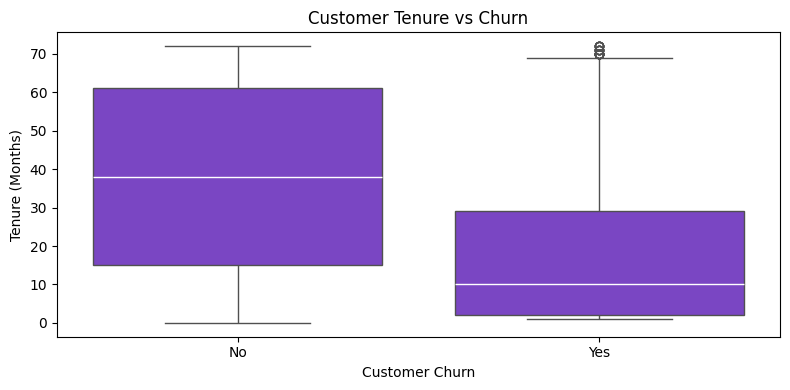

In [36]:
# Create a boxplot to compare customer tenure across churn categories
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_model,
    x="Churn",
    y="tenure",
    color="#7731d8",
    medianprops={"color": "white"}
)

# Add chart title and axis labels
plt.title("Customer Tenure vs Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Tenure (Months)")

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Tenure by Churn Status:**

1. **Customers who churned have substantially shorter tenures** than customers who remained with the company. The median tenure for churned customers is approximately 10 months, compared with approximately 38 months for retained customers.

2. The middle 50% (interquartile range) of churned customers is concentrated within the first 30 months, indicating that **churn occurs predominantly during the early stages of the customer lifecycle**.

3. In contrast, customers who did not churn exhibit a much wider tenure distribution, with many remaining customers having tenures extending beyond 60 months, suggesting strong long-term customer loyalty.

4. A small number of high-tenure customers also churn, as indicated by the few outliers near 70–72 months. This suggests that although uncommon, long-standing customers are not completely immune to churn.

---
**Business Insight**

**Customer tenure emerges as one of the strongest predictors of churn** in the dataset.

The findings indicate that customer attrition is heavily concentrated among relatively new customers, while customers who remain beyond the early stages of their lifecycle are substantially more likely to stay with the company. This highlights the importance of onboarding, early engagement and proactive retention initiatives during the first one to two years of the customer relationship.

#### 5.7.2 Tenure Cohort vs Churn

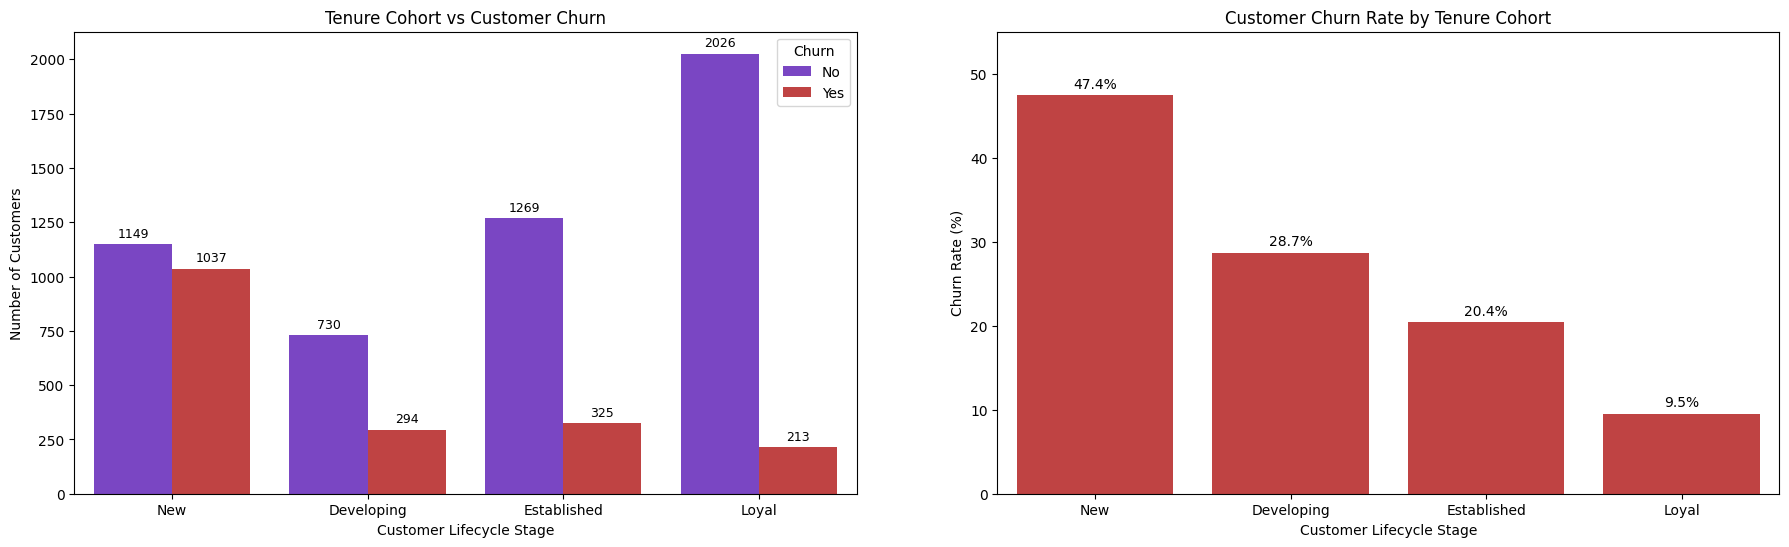

In [37]:
# Calculate the churn rate for each tenure cohort
cohort_churn_rate = (
    df_model
    .groupby("TenureCohort", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex([
        "New",
        "Developing",
        "Established",
        "Loyal"
    ])
    .reset_index(name="ChurnRate")
)

# Define the order of customer lifecycle stages
cohort_order = [
    "New",
    "Developing",
    "Established",
    "Loyal"
]

# Create side-by-side visualisations
plt.figure(figsize=(22, 6))

# Plot 1: Customer Churn by Tenure Cohort (Counts)
plt.subplot(1, 2, 1)

ax1 = sns.countplot(
    data=df_model,
    x="TenureCohort",
    hue="Churn",
    order=cohort_order,
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    }
)

# Add chart title and axis labels
plt.title("Tenure Cohort vs Customer Churn")
plt.xlabel("Customer Lifecycle Stage")
plt.ylabel("Number of Customers")

# Add legend
plt.legend(title="Churn")

# Display the count above each bar
for bar in ax1.patches:
    if bar.get_height() == 0:
        continue

    ax1.annotate(
        f"{int(bar.get_height())}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Plot 2: Customer Churn Rate by Tenure Cohort
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    data=cohort_churn_rate,
    x="TenureCohort",
    y="ChurnRate",
    order=cohort_order,
    color="#d32f2f"
)

# Add chart title and axis labels
plt.title("Customer Churn Rate by Tenure Cohort")
plt.xlabel("Customer Lifecycle Stage")
plt.ylabel("Churn Rate (%)")

# Display the churn rate above each bar
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Set y-axis limit for consistency
plt.ylim(0, 55)

# Adjust spacing between plots
plt.subplots_adjust(wspace=0.18)

# Display the plots
plt.show()

**Observations on Tenure Cohort vs Customer Churn**

1. The New customer cohort exhibits the highest level of churn, with 1,037 customers churning and a churn rate of 47.4%, indicating that **nearly one in every two newly acquired customers leaves the service.**

2. The churn rate decreases steadily as customers progress through successive lifecycle stages. Customers in the Developing cohort have a churn rate of 28.7%, followed by 20.4% for the Established cohort.

3. The Loyal cohort demonstrates the strongest customer retention, with the lowest churn rate of only 9.5%, despite representing the largest customer segment.


While the number of retained customers increases across later lifecycle stages, the number of churned customers declines considerably- (47.4% → 28.7% → 20.4% → 9.5%), suggesting that **customer loyalty strengthens with longer service duration.**

---
**Business Insight**

    Customer churn is heavily concentrated during the early stages of the customer lifecycle

Once customers remain with the company long enough to progress beyond the initial tenure period, their likelihood of churning decreases substantially.
This highlights the importance of prioritizing customer onboarding, early engagement and proactive retention initiatives for newly acquired customers, as improving retention during the first year is likely to yield the greatest reduction in overall churn.

#### 5.7.3 Total Charges vs Churn

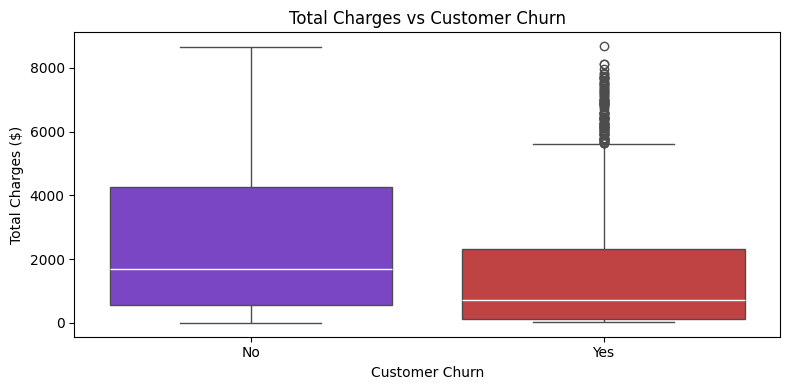

In [38]:
# Create a boxplot to compare total customer charges across churn categories
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_model,
    x="Churn",
    y="TotalCharges",
    hue="Churn",
    palette={
        "No": "#7731d8",
        "Yes": "#d32f2f"
    },
    legend=False,
    medianprops={"color": "white"}
)

# Add chart title and axis labels
plt.title("Total Charges vs Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Total Charges ($)")

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

**Observations on Total Charges by Churn Status:**

1. Customers who did not churn generally have higher total charges than customers who churned, as indicated by the higher median and broader distribution of total charges.

2. Customers who churned have a median total charge that is substantially lower, suggesting that many customers leave before accumulating significant lifetime revenue.

3. The distribution of total charges among retained customers spans a much wider range, reflecting the presence of many long-tenure customers who have remained with the company and generated higher cumulative revenue.

4. A number of customers with high total charges have also churned, as shown by the upper outliers in the churned group. These customers likely represent long-term customers who eventually discontinued the service despite contributing substantial lifetime revenue.

---
**Business Insight**

The results indicate that **customers who churn generally have lower lifetime value because they leave earlier in their relationship with the telecom provider**.

However, the presence of several high-value churned customers suggests that **customer attrition is not limited to newly acquired customers.**

While early-stage retention remains the greatest opportunity, **retaining long-tenure, high-value customers is also important** because losing these customers represents a significant revenue loss.

### 5.8 Correlation Analysis

**Purpose:**

To examine the relationships among key numerical customer attributes, such as tenure, monthly charges and total charges, and understand how they are connected.

This analysis also helps identify highly correlated features that may influence customer churn and helps in feature selection for predictive modelling.

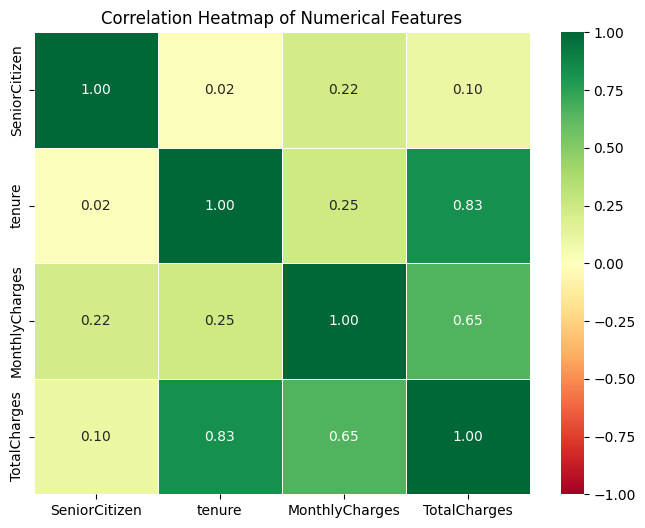

In [39]:
# Select numerical variables for correlation analysis
corr_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Create the correlation matrix
corr_matrix = df_model[corr_cols].corr()

# Set the figure size
plt.figure(figsize=(8, 6))

# Generate the correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

# Add chart title
plt.title("Correlation Heatmap of Numerical Features")

# Display the plot
plt.show()

**Observations on Correlation Analysis**

* **Strong Positive Correlation:** There is a strong positive correlation (**0.83**) between **`tenure`** and **`TotalCharges`**. This is expected, as customers who remain with the company for longer naturally accumulate higher total charges over time.

* **Moderate Positive Correlation:** **`MonthlyCharges`** shows a moderately strong positive correlation (**0.65**) with **`TotalCharges`**, indicating that customers with higher monthly bills generally contribute more cumulative revenue.

* **Weak Relationships:** **`SeniorCitizen`** has only weak correlations with the other numerical variables, suggesting that senior citizen status is largely independent of customer tenure, monthly charges, and total charges.

* **Potential Multicollinearity:** The strong relationship between **`tenure`** and **`TotalCharges`**, along with the moderate relationship between **`MonthlyCharges`** and **`TotalCharges`**, indicates that these variables capture overlapping information. This should be considered during feature selection, particularly for models that are sensitive to multicollinearity.

---
**Business Insight**

The correlation analysis reinforces that **customer tenure is a key driver of customer lifetime value**, with longer-tenured customers generating higher cumulative revenue. While **`MonthlyCharges`** reflects a customer's current spending level, **`TotalCharges`** captures the combined effect of monthly spending and customer longevity.

Together, these findings suggest that retaining customers for longer not only reduces churn but also maximizes long-term revenue. They also highlight the importance of selecting numerical features carefully during model development to balance predictive performance and avoid redundant information.


### 5.9 Key Insights from EDA

The Exploratory Data Analysis revealed several important patterns associated with customer churn and highlighted the key factors that should be considered during predictive modelling.

---
* **Customer churn is a significant business concern**, with approximately **26.5%** of customers leaving the telecom service. This class imbalance indicates that evaluation metrics such as precision, recall, F1-score, and ROC-AUC will be more appropriate than accuracy when assessing predictive models.

---
* **Customer lifecycle emerged as one of the strongest indicators of churn.** Customers with shorter tenures, particularly those in the **New** lifecycle cohort, exhibited substantially higher churn rates than long-term customers. Churn declined consistently as customers progressed through successive lifecycle stages, highlighting the importance of early customer engagement and retention.

---
* **Contract type has a strong influence on customer retention.** Customers on **month-to-month contracts** experienced the highest churn rates, whereas customers with longer-term contracts demonstrated considerably stronger retention. This suggests that contractual commitment plays an important role in reducing customer attrition.

---
* **Service adoption is closely associated with customer retention.** Customers subscribing to value-added services such as **Online Security** and **Tech Support** were significantly less likely to churn than customers who did not use these services. Conversely, **Fiber optic** customers exhibited the highest churn rate among all internet service types.

---
* **Billing behaviour also differentiates churn risk.** Customers using **Electronic Check** and **Paperless Billing** showed substantially higher churn rates than customers using automatic payment methods or traditional paper billing, indicating that payment behaviour may serve as a useful behavioural indicator of churn.

---
* **Customer demographics exhibited varying levels of influence.** While **Gender** showed little relationship with churn, **Senior Citizen**, **Partner**, and **Dependents** demonstrated meaningful differences in churn behaviour, suggesting that these variables may contribute to predictive performance.

---
* **Monthly Charges** were generally higher for customers who churned, whereas customers who remained with the company accumulated substantially higher **Total Charges**, reflecting longer customer lifetimes and greater lifetime value.

---
* **Correlation analysis identified a strong relationship between `tenure` and `TotalCharges`**, indicating that these variables contain overlapping information. This relationship should be considered during feature selection to reduce redundancy and improve model interpretability.

---
**Overall Business Insight**

The EDA indicates that customer churn is influenced by a combination of **customer lifecycle, contract commitment, service adoption, billing behaviour, and pricing characteristics**, rather than any single factor in isolation. These findings provide a strong foundation for the subsequent **Feature Engineering** and **Predictive Modelling** stages, where the identified patterns will be transformed into features and evaluated to build an effective customer churn prediction model.

## 6. Feature Engineering

Based on my research about the telecommunications industry and insights obtained during Exploratory Data Analysis, the following engineered features were created:

- Customer Tenure Cohort
- Monthly Charge Band
- Service Bundle Count
- Revenue Per Month

### 6.1 Customer Tenure Cohort

The TenureCohort feature groups customers into business-defined lifecycle stages based on their tenure. The feature was created during the data preparation stage to support both the exploratory analysis and predictive modelling workflow.

Grouping customers into lifecycle stages provides a more interpretable representation of customer maturity and helps the model capture non-linear churn patterns that may not be evident from the continuous tenure variable alone.

---
**Intervals** (in Months):
- 0-12   - New
- 12-24  - Developing
- 24-48  - Established
- 48-72  - Loyal



In [40]:
# Display the distribution of the engineered feature
display(
    pd.DataFrame({
        "Count": df_model["TenureCohort"].value_counts().sort_index(),
        "Percentage": (
            df_model["TenureCohort"]
            .value_counts(normalize=True)
            .sort_index() * 100
        ).round(2)
    })
)

,Count,Percentage
TenureCohort,,
New,2186,31.04
Developing,1024,14.54
Established,1594,22.63
Loyal,2239,31.79


#### **Observations on Customer Tenure Cohort**

- The TenureCohort feature was successfully created by grouping customers into four business-defined lifecycle stages: New, Developing, Established and Loyal.

- The customer base is reasonably distributed across the four cohorts, with Loyal (31.79%) and New (31.04%) customers representing the largest segments, followed by Established (22.63%) and Developing (14.54%) customers.

- Transforming the continuous tenure variable into distinct lifecycle stages provides a more interpretable representation of the customer journey and may help capture behavioural differences across different stages of the customer lifecycle.

- Exploratory analysis indicates that churn rates vary considerably across the four tenure cohorts, suggesting that TenureCohort may provide useful information for distinguishing customers with different levels of churn risk.

---
The predictive contribution of TenureCohort will be evaluated later during the model interpretation stage to determine whether it provides additional information beyond the original tenure variable.

### 6.2 Monthly Charge Band

Customer monthly charges were grouped into pricing tiers to capture potential differences in churn behaviour across spending levels. Converting the continuous MonthlyCharges variable into categorical pricing bands allows the model to identify non-linear relationships between customer spending and churn.

Quartile-based binning was used to create four balanced pricing tiers, ensuring that each category contains a similar number of customers.

For exploratory analysis, the pricing bands are illustrated using the complete modelling dataset.

**During model development, the feature is reconstructed using quartile boundaries exclusively from the training dataset to maintain a leakage-free modelling workflow.**

In [41]:
# Create Monthly Charge Bands using quartile-based binning
df_model["MonthlyChargeBand"] = pd.qcut(
    df_model["MonthlyCharges"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [42]:
# Display the distribution of the engineered feature
display(
    pd.DataFrame({
        "Count": df_model["MonthlyChargeBand"].value_counts().sort_index(),
        "Percentage": (
            df_model["MonthlyChargeBand"]
            .value_counts(normalize=True)
            .sort_index() * 100
        ).round(2)
    })
)

,Count,Percentage
MonthlyChargeBand,,
Low,1762,25.02
Medium,1766,25.07
High,1757,24.95
Very High,1758,24.96


**Observations on Monthly Charge Bands:**

- The MonthlyChargeBand feature was successfully created by dividing customers into four quartile-based pricing tiers: Low, Medium, High and Very High.

- Each pricing tier contains approximately 25% of the customer base, confirming that quartile-based binning produced a balanced distribution across all categories.

- Transforming the continuous MonthlyCharges variable into discrete pricing bands provides a more interpretable representation of customer spending and may help capture non-linear relationships that are not easily represented by the original continuous variable.

- Exploratory analysis indicates that customers in the higher pricing bands generally exhibit higher churn rates than those in the lower pricing bands.

This suggests that MonthlyChargeBand may provide useful information for distinguishing customers with different levels of churn risk.

---
The predictive contribution of MonthlyChargeBand will be evaluated later during the model interpretation stage to determine whether it provides additional information beyond the original MonthlyCharges variable.

### 6.3 Service Bundle Count


This feature represents the total number of optional value-added services subscribed to by each customer. It serves as a measure of customer engagement or product stickiness, based on the assumption that customers using a larger number of services are more integrated with the telecom provider and may therefore be less likely to churn.

Only optional value-added services were included in this feature. Core telecom services such as PhoneService and MultipleLines were intentionally excluded, as they represent basic connectivity rather than additional service adoption.

In [43]:
# List of optional value-added services
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Create ServiceBundleCount by counting subscribed services
df_model["ServiceBundleCount"] = (
    df_model[service_columns] == "Yes"
).sum(axis=1)

In [44]:
# Display the distribution of the engineered feature
display(
    pd.DataFrame({
        "Count": df_model["ServiceBundleCount"].value_counts().sort_index(),
        "Percentage": (
            df_model["ServiceBundleCount"]
            .value_counts(normalize=True)
            .sort_index() * 100
        ).round(2)
    })
)

print("\nAverage Service Bundle Count by Churn Status:\n")

print(
    df_model
    .groupby("Churn")["ServiceBundleCount"]
    .mean()
    .round(2)
)

,Count,Percentage
ServiceBundleCount,,
0,2219,31.51
1,966,13.72
2,1033,14.67
3,1118,15.87
4,852,12.10
5,571,8.11
6,284,4.03



Average Service Bundle Count by Churn Status:

Churn
No     2.14
Yes    1.77
Name: ServiceBundleCount, dtype: float64


**Observations on Service Bundle Count:**

- The ServiceBundleCount feature was successfully created by counting the number of subscribed value-added services for each customer, resulting in values ranging from 0 to 6.

- Approximately 31.5% of customers do not subscribe to any optional value-added services, while progressively fewer customers subscribe to a larger number of services, indicating varying levels of service adoption across the customer base.

- Exploratory analysis shows that customers who churned subscribe to fewer value-added services on average (1.77) than customers who remained (2.14). This suggests that the level of service adoption may reflect differences in customer engagement.

- These observations indicate that ServiceBundleCount may provide useful information for distinguishing customers with different churn behaviours.

---
The predictive contribution of ServiceBundleCount will be evaluated later during the model interpretation stage to determine whether it provides additional information beyond the original service-related variables.

### 6.4 Revenue Per Month

**Purpose**

The **RevenuePerMonth** feature measures the average monthly revenue generated by each customer throughout their relationship with the telecom provider.

- It combines TotalCharges and tenure into a single feature, providing a normalized measure of customer spending over time.

- Customers with high monthly revenue but short tenure may represent recently acquired, high-value customers who have not yet developed long-term loyalty and may therefore be at greater risk of churn.

---
The predictive value of this engineered feature will be evaluated at later analysis stage

In [45]:
import numpy as np

# Calculate the average monthly revenue generated by each customer.
# For customers with zero tenure, MonthlyCharges is used to avoid division by zero.

df_model["RevenuePerMonth"] = np.where(
    df_model["tenure"] > 0,
    df_model["TotalCharges"] / df_model["tenure"],
    df_model["MonthlyCharges"]
)

In [46]:
# Display summary statistics for the engineered feature
print("Revenue Per Month Summary Statistics:\n")

display(
    df_model["RevenuePerMonth"]
    .describe()
    .round(2)
)

# Compare the feature across churn groups
print("\nRevenue Per Month by Churn Status:\n")

display(
    df_model
    .groupby("Churn")["RevenuePerMonth"]
    .describe()
    .round(2)
)

Revenue Per Month Summary Statistics:



,RevenuePerMonth
count,7043.00
mean,64.76
std,30.19
min,13.78
25%,35.94
50%,70.34
75%,90.17
max,121.40



Revenue Per Month by Churn Status:



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.14,13.78,25.35,63.98,87.72,120.75
Yes,1869.0,74.43,24.96,14.15,57.98,79.31,93.93,121.40


**Observations on Revenue Per Month**

- The RevenuePerMonth feature was successfully created by combining TotalCharges and tenure to estimate each customer's average monthly revenue.

- The feature ranges from 13.78 to 121.40, with an average monthly revenue of 64.76, indicating considerable variation in customer spending across the customer base.

- Exploratory analysis shows that customers who churned have a higher average RevenuePerMonth (74.43) than customers who remained (61.27). The median value is also higher for churned customers (79.31 vs. 63.98), suggesting that this pattern is consistent across the distribution.

- These findings indicate that RevenuePerMonth may capture customer spending behaviour that is relevant to churn prediction.

---
As RevenuePerMonth is derived from TotalCharges and tenure, its contribution to the predictive model will be evaluated during the model interpretation stage to determine whether it provides additional information beyond the original variables.

### 6.5 Feature Verification

The engineered features were reviewed to confirm that they were successfully created and correctly added to the modelling dataset. This verification ensures that all new features are available for the subsequent feature selection and model development stages.

In [47]:
# List the engineered features created during feature engineering
engineered_features = [
    "TenureCohort",
    "MonthlyChargeBand",
    "ServiceBundleCount",
    "RevenuePerMonth"
]

# Display the first five records to verify feature creation
df_model[engineered_features].head()

,TenureCohort,MonthlyChargeBand,ServiceBundleCount,RevenuePerMonth
0,New,Low,1,29.850000
1,Established,Medium,2,55.573529
2,New,Medium,2,54.075000
3,Established,Medium,3,40.905556
4,New,High,0,75.825000


In [48]:
# Verify the data types of engineered features
df_model[engineered_features].dtypes

,0
TenureCohort,category
MonthlyChargeBand,category
ServiceBundleCount,int64
RevenuePerMonth,float64


**Observations on Feature Verification**

- All four engineered features (TenureCohort, MonthlyChargeBand, ServiceBundleCount, and RevenuePerMonth) were successfully created and added to the modelling dataset.

- A sample of the dataset confirms that the engineered features have been populated correctly and align with the underlying customer records.

- The data types are appropriate for subsequent modelling, with TenureCohort and MonthlyChargeBand stored as categorical variables, ServiceBundleCount as an integer feature, and RevenuePerMonth as a continuous numerical feature.

The feature engineering process resulted in four new features that capture customer lifecycle stage, spending tier, service adoption, and average monthly revenue. These engineered features, together with the original cleaned variables, form the modelling dataset used in the next stage.

The next section evaluates the complete feature set and prepares the data for machine learning through feature selection and encoding.

## 7. Basic Model Implementation

### 7.1 Introduction

The objective of this section is to develop a machine learning model capable of predicting customer churn using the cleaned dataset and the engineered features created in the previous stage.

The modelling process follows a structured workflow that includes data preparation, preprocessing, model training, performance evaluation, and validation to ensure that the resulting model generalises well to unseen customer data.

A **Logistic Regression** classifier is selected as the baseline model. The model's performance will be evaluated using multiple classification metrics and subsequently improved through hyperparameter tuning. The predictive relevance of both the original and engineered features will also be assessed to identify the variables that contribute most to customer churn prediction.

### 7.2 Problem Formulation and Model Selection

**Problem Formulation**

Customer churn prediction is formulated as a **supervised binary classification** problem, where the objective is to predict whether a customer is likely to churn ("Yes") or remain ("No") based on their demographic characteristics, subscribed services, billing information and the engineered features developed in the previous section.

Accurately identifying customers at risk of churning enables telecom providers to implement targeted retention strategies, improve customer lifetime value and reduce revenue loss.

---

**Model Selection**

A Logistic Regression classifier is selected as the baseline model due to its simplicity, interpretability and effectiveness for binary classification problems.

The model estimates the probability of customer churn while providing interpretable coefficients that quantify the influence of each feature on the likelihood of churn. This makes Logistic Regression particularly suitable for understanding the key drivers of customer attrition in addition to generating accurate predictions.

---
**Model Evaluation Criteria**

As identified during the Exploratory Data Analysis, the dataset exhibits a moderate class imbalance, with approximately 26.5% of customers belonging to the churn class. Therefore, model performance will be evaluated using multiple classification metrics rather than relying solely on accuracy.

**The primary evaluation metrics include:**

- **Accuracy:** Overall proportion of correctly classified customers

- **Precision:** Proportion of predicted churners who actually churn

- **Recall:** Proportion of actual churners correctly identified by the model

- **F1-Score:** Harmonic mean of precision and recall, providing a balanced measure of classification performance

- **ROC-AUC:** Measures the model's ability to distinguish between churning and non-churning customers across different classification thresholds

### 7.3 Preparing the Modelling Dataset

The modelling dataset created during the data preparation stage and enriched through feature engineering is now finalised for machine learning.

Before model development, the non-predictive customer identifier is removed to prevent data leakage and ensure that the model is trained only on meaningful customer attributes.

In [49]:
# Remove the customer identifier before model development
df_model = df_model.drop(columns=["customerID"])

# Display the dimensions of the modelling dataset
print(f"Modelling Dataset Shape: {df_model.shape}")

# Display the first five observations
df_model.head()

Modelling Dataset Shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCohort,MonthlyChargeBand,ServiceBundleCount,RevenuePerMonth
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,Low,1,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,Established,Medium,2,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,Medium,2,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,Established,Medium,3,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,High,0,75.825000


**Observations on the Modelling Dataset**

- The modelling dataset contains 7,043 customer records and 24 variables, including both the original customer attributes and the engineered features created during the feature engineering stage.

- The customerID column has been removed as it serves only as a unique identifier and does not provide predictive information for churn modelling.
---
The dataset is now ready for defining the feature matrix, target variable, and subsequent preprocessing prior to model training.

#### 7.3.1 Dataset Verification

In [50]:
# Verify the modelling dataset

print(f"Number of observations : {df_model.shape[0]}")
print(f"Number of features     : {df_model.shape[1] - 1}")  # Excluding target variable

print("\nTarget Variable Distribution:")
print(df_model["Churn"].value_counts())

print("\nMissing Values:")
print(df_model.isnull().sum().sum())

Number of observations : 7043
Number of features     : 23

Target Variable Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Missing Values:
0


**Observations on Dataset Verification**

- The modelling dataset contains 7,043 customer records and 23 predictor variables, excluding the target variable (Churn).

- The target class distribution remains unchanged, indicating that no observations were lost during data preparation.

- No missing values are present in the dataset, confirming that all preprocessing steps were successfully completed.

### 7.4 Feature Matrix and Target Variable

Before training a supervised machine learning model, the modelling dataset must be separated into a set of features and the target variable.

- The target variable is Churn, which indicates whether a customer has discontinued the telecom service.

- The remaining variables, including customer demographics, subscribed services, billing information and engineered features, form the feature matrix used to predict customer churn.

---
Separating the feature matrix (X) from the target vector (y) ensures that the model learns only from valid predictor variables while preventing the target variable from being inadvertently included during training, thereby eliminating the risk of target leakage.

In [51]:
# Separate the predictor variables and target variable

# Create the feature matrix by removing the target column
X = df_model.drop(columns=["Churn"])

# Create the target vector
y = df_model["Churn"]

# Display the dimensions of the feature matrix and target vector
print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

# Display the target class distribution
print("\nTarget Class Distribution:")
print(y.value_counts())

# Display the predictor variables used for modelling
display(
    pd.DataFrame({
        "Predictor Variables": X.columns
    })
)

Feature Matrix Shape : (7043, 23)
Target Vector Shape  : (7043,)

Target Class Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,Predictor Variables
0,gender
1,SeniorCitizen
2,Partner
3,Dependents
4,tenure
5,PhoneService
6,MultipleLines
7,InternetService
8,OnlineSecurity
9,OnlineBackup


**Observations on the Feature Matrix and Target Variable**

- The modelling dataset was successfully separated into a feature matrix (X) containing 23 predictor variables and a target vector (y) containing the customer churn labels.

- The predictor variables include customer demographics, subscribed services, billing information, and the four engineered features (TenureCohort, MonthlyChargeBand, ServiceBundleCount and RevenuePerMonth), providing a comprehensive set of inputs for churn prediction.

- The target variable (Churn) has been excluded from the feature matrix, ensuring that the model is trained only on legitimate predictor variables and eliminating the risk of target leakage.
---
The feature matrix is now ready for train-test splitting and the construction of a leakage-free preprocessing pipeline.

### 7.5 Train-Test Split

Before training a machine learning model, the modelling dataset must be divided into separate training and testing subsets.

- The training dataset is used to learn the relationship between customer characteristics and churn behaviour, while the testing dataset is reserved for evaluating the model on previously unseen customers. This separation provides an unbiased estimate of the model's ability to generalise to new data.

- Since the Telco Customer Churn dataset exhibits moderate class imbalance, a stratified train-test split is employed. Stratification preserves the original proportion of churn and non-churn customers in both subsets, ensuring that the training and testing datasets remain representative of the overall population.

- An 80:20 split is adopted, where approximately 80% of the observations are allocated for model training and the remaining 20% are reserved for model evaluation.

- A fixed random seed (random_state = 42) is specified to ensure that the data split is reproducible.

In [52]:
# Import the train-test split function
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Display the dimensions of each dataset
print(f"Training Feature Matrix : {X_train.shape}")
print(f"Testing Feature Matrix  : {X_test.shape}")
print(f"Training Target Vector  : {y_train.shape}")
print(f"Testing Target Vector   : {y_test.shape}")

# Verify that the class distribution has been preserved
print("\nTraining Set Class Distribution")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting Set Class Distribution")
print(y_test.value_counts(normalize=True).round(3))

Training Feature Matrix : (5634, 23)
Testing Feature Matrix  : (1409, 23)
Training Target Vector  : (5634,)
Testing Target Vector   : (1409,)

Training Set Class Distribution
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

Testing Set Class Distribution
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


**Observations on Train-Test Split**

- The modelling dataset was successfully divided into 5634 training observations and 1409 testing observations, following the intended 80:20 train-test split.

- Stratified sampling preserved the original class distribution across both subsets, with approximately 73.5% non-churn and 26.5% churn customers in both the training and testing datasets.

- Preserving the class distribution ensures that both subsets remain representative of the original dataset, reducing the risk of biased model evaluation.
---
The testing dataset will remain unseen during model training and will be used exclusively to evaluate the model's ability to generalise to new customer data.

### 7.5.1 Leakage-Free Reconstruction of Monthly Charge Bands


Purpose:

To reconstruct the engineered MonthlyChargeBand feature using quartile
boundaries learned exclusively from the training dataset. This ensures
that the feature engineering process does not incorporate information
from the testing dataset, thereby preventing data leakage. The same
training-derived bin boundaries are subsequently applied unchanged to
both the training and testing datasets to maintain a consistent and
reproducible transformation workflow.


In [53]:
# Reconstruct MonthlyChargeBand using training-set quartile boundaries
# to ensure a leakage-free feature engineering workflow.

# Create copies to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Learn quartile boundaries using ONLY the training data
_, monthlycharge_bins = pd.qcut(
    X_train["MonthlyCharges"],
    q=4,
    labels=False,
    retbins=True
)

# Extend the outer bin boundaries to infinity so that any unseen values
# in the test set are assigned to a valid band.
monthlycharge_bins[0] = -float("inf")
monthlycharge_bins[-1] = float("inf")

# Define Monthly Charge Band labels
labels = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

# Apply the same training-derived boundaries to both datasets
X_train["MonthlyChargeBand"] = pd.cut(
    X_train["MonthlyCharges"],
    bins=monthlycharge_bins,
    labels=labels,
    include_lowest=True
)

X_test["MonthlyChargeBand"] = pd.cut(
    X_test["MonthlyCharges"],
    bins=monthlycharge_bins,
    labels=labels,
    include_lowest=True
)

# Verify successful feature creation
print("MonthlyChargeBand reconstructed using training-set quartile boundaries.")

display(
    X_train[
        ["MonthlyCharges", "MonthlyChargeBand"]
    ].sample(5, random_state=42)
)

print(f"Missing values in X_train: {X_train['MonthlyChargeBand'].isna().sum()}")
print(f"Missing values in X_test : {X_test['MonthlyChargeBand'].isna().sum()}")

MonthlyChargeBand reconstructed using training-set quartile boundaries.


,MonthlyCharges,MonthlyChargeBand
5426,75.20,High
3434,54.60,Medium
3343,20.10,Low
5015,65.00,Medium
5229,107.55,Very High


Missing values in X_train: 0
Missing values in X_test : 0


The MonthlyChargeBand feature is reconstructed after the train-test split. Quartile boundaries are learned exclusively from the training dataset and then applied unchanged to both the training and testing datasets. This prevents distribution leakage while ensuring a consistent transformation for model development.

### 7.6 Building a Leakage-Free Preprocessing Pipeline

Machine learning algorithms require numerical input features. Since the Telco Customer Churn dataset contains both numerical and categorical variables, appropriate preprocessing is required before model training.

Numerical variables are measured on different scales and therefore require standardisation to ensure that no feature disproportionately influences the learning process. Categorical variables must also be converted into numerical representations that can be interpreted by the model.

A critical objective of this stage is to prevent data leakage. Applying preprocessing to the entire dataset before splitting the data would allow information from the testing set to influence the training process, resulting in overly optimistic performance estimates.

To eliminate this risk, all preprocessing steps are incorporated into a Scikit-learn Pipeline. The preprocessing parameters are learned exclusively from the training dataset and are then applied unchanged to the testing dataset.

The preprocessing workflow consists of three steps:

1. Separate the predictor variables into numerical and categorical features.

2. Standardise numerical features using **StandardScaler** and encode categorical features using **One-Hot Encoder**.

3. Combine both transformations using a **ColumnTransformer**, creating a unified preprocessing pipeline that will later be integrated with the Logistic Regression model.

In [54]:
# Import preprocessing and pipeline utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical feature columns
# Numerical features will be standardised using StandardScaler,
# while categorical features will be transformed using One-Hot Encoding.

numerical_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

# Display the identified feature groups
print(f"Number of Numerical Features   : {len(numerical_features)}")
print(f"Number of Categorical Features : {len(categorical_features)}")
print(f"Total Predictor Variables      : {len(numerical_features) + len(categorical_features)}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

# Define preprocessing transformers

# Standardise numerical features
numerical_transformer = StandardScaler()

# Convert categorical features into binary indicator variables
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Combine preprocessing steps into a single transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\nPreprocessing pipeline created successfully.")

Number of Numerical Features   : 6
Number of Categorical Features : 17
Total Predictor Variables      : 23

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceBundleCount', 'RevenuePerMonth']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureCohort', 'MonthlyChargeBand']

Preprocessing pipeline created successfully.


**Observations on the Preprocessing Pipeline**

- The predictor variables were successfully classified into** 6 numerical** and **17 categorical** features, ensuring that each feature type will undergo the appropriate preprocessing transformation.

- Numerical features, including the engineered **RevenuePerMonth** and **ServiceBundleCount**, will be standardised using **StandardScaler**, while categorical features such as **TenureCohort** and **MonthlyChargeBand** will be encoded using **One-Hot Encoding**.

- The preprocessing steps have been integrated into a single **ColumnTransformer**, providing a consistent and reproducible transformation workflow for all predictor variables.

---
The preprocessing pipeline will be fitted exclusively on the training dataset and then applied unchanged to the testing dataset. This prevents data leakage and ensures that the model is evaluated on genuinely unseen customer data.

### 7.7 Baseline Logistic Regression

- Logistic Regression is selected as the baseline classification algorithm because it is well suited for binary classification problems, produces probability estimates, and provides interpretable model coefficients that facilitate understanding of the factors influencing customer churn.

- The model is trained using the leakage-free preprocessing pipeline developed in the previous section. By integrating preprocessing and model training into a single Scikit-learn Pipeline, all transformations are learned exclusively from the training data and applied consistently to unseen testing data, thereby preventing data leakage.

- Since the Telco Customer Churn dataset exhibits moderate class imbalance (approximately 26% churn and 74% non-churn), the **model is configured with class_weight='balanced'**. This automatically assigns higher importance to the minority churn class during optimisation, reducing bias towards the majority class and improving the model's ability to identify customers who are likely to churn.

- Finally, Logistic Regression is **optimised by minimising the log-loss (cross-entropy) objective function**, enabling the model to estimate the probability of churn for each customer rather than producing only binary class predictions.

- These probability estimates are particularly valuable for customer retention strategies, where customers can be ranked according to their predicted churn risk.

#### 7.7.1 Baseline Model Construction

**The leakage-free preprocessing pipeline and the Logistic Regression classifier are now combined into a single Scikit-learn Pipeline.**

- Using a unified pipeline ensures that every preprocessing step, including feature scaling and one-hot encoding, is fitted exclusively on the training data and then applied consistently to unseen data during prediction.

- This prevents data leakage, improves reproducibility and mirrors how machine learning models are deployed in production environments.

- The Logistic Regression model is configured with class_weight='balanced' to account for class imbalance and max_iter=1000 to ensure reliable convergence during optimisation.

In [55]:
# Import the required classes

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the complete modelling pipeline by combining the
# preprocessing transformer and the Logistic Regression classifier.

baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                class_weight="balanced",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

print("Baseline Logistic Regression pipeline created successfully.")

Baseline Logistic Regression pipeline created successfully.


**Interpretation**

The baseline modelling pipeline has been created successfully and is now ready for training.

By combining preprocessing and Logistic Regression into a single pipeline, the entire workflow is executed consistently from start to finish. This prevents data leakage, reduces manual preprocessing, and allows the same pipeline to be reused during model evaluation, cross-validation, hyperparameter tuning, and prediction.

#### 7.7.2 Baseline Model Training

The baseline pipeline is now trained using the training dataset.

Once the model has been fitted, it is used to generate both class predictions and churn probabilities for the unseen testing dataset.

The predicted classes are used to evaluate classification performance, while the predicted probabilities are used to compute threshold-independent metrics such as ROC-AUC and to rank customers according to their likelihood of churn.

In [56]:
# Train the baseline modelling pipeline
baseline_pipeline.fit(X_train, y_train)

# Predict customer churn labels for the testing dataset
y_pred = baseline_pipeline.predict(X_test)

# Predict customer churn probabilities for the testing dataset
y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


The baseline Logistic Regression model has now been trained using the leakage-free preprocessing pipeline.

For each customer in the testing dataset, the model generates two outputs:

- **Predicted class** (Churn or No Churn)

- **Predicted probability of churn**

While the predicted class is used to evaluate the model's classification performance, the probability estimates provide a more detailed view of churn risk by indicating how likely each customer is to leave. In the next section, these predictions will be evaluated using multiple performance metrics to assess how well the model generalises to unseen data.

### 7.8 Model Evaluation

The performance of the baseline Logistic Regression model is evaluated using multiple classification metrics.

- Since the dataset is moderately imbalanced, relying solely on accuracy can be misleading.

- Therefore, precision, recall, F1-score and ROC-AUC are also reported to provide a more comprehensive assessment of the model's ability to distinguish between customers who churn and those who remain.

#### 7.8.1 Classification Metrics

The performance of the baseline Logistic Regression model is evaluated using the unseen testing dataset.

Since customer churn is a moderately imbalanced classification problem, **accuracy alone is not sufficient** to assess model performance. Therefore, multiple evaluation metrics, including **Precision, Recall, F1-score and ROC-AUC,** are used to provide a more comprehensive assessment of the model's ability to distinguish between customers who churn and those who remain.

In [57]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

# Calculate overall evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob
)

# Generate the classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    output_dict=True
)

# Create a summary table of key evaluation metrics
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        report["Churn"]["precision"],
        report["Churn"]["recall"],
        report["Churn"]["f1-score"],
        roc_auc
    ]
})

# Round values for presentation
metrics_df["Score"] = metrics_df["Score"].round(3)

# Display the evaluation metrics
display(metrics_df)

# Display the complete classification report
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

print("\nPositive Class Evaluated : Churn")

,Metric,Score
0,Accuracy,0.734
1,Precision,0.499
2,Recall,0.794
3,F1-Score,0.613
4,ROC-AUC,0.842



Classification Report

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409


Positive Class Evaluated : Churn


**Observations on Classification Metrics**

- The baseline Logistic Regression model achieved an **Accuracy of 73.4%** and a **ROC-AUC of 0.842**, indicating good overall discrimination between customers who churn and those who remain. The high ROC-AUC suggests that the model ranks customers by churn risk effectively across different decision thresholds.

- The model achieved a **Recall of 79.7%** for the churn class, meaning it **correctly identified nearly 8 out of every 10 customers who actually churned**. This is desirable in customer retention scenarios, where failing to identify a potential churner is generally more costly than contacting a loyal customer.

- The **Precision of 49.9%** indicates that approximately half of the customers predicted to churn actually did so. This relatively lower precision reflects a higher number of false positives, which is an expected trade-off when optimising for higher recall using class_weight='balanced'.

- The resulting **F1-Score of 0.614** demonstrates a reasonable balance between precision and recall, confirming that the model is effective at identifying churners while maintaining acceptable overall classification performance.

---
Overall, the baseline model provides a strong starting point for churn prediction. The next sections further evaluate its performance using the confusion matrix, generalisation analysis, and hyperparameter tuning to determine whether additional improvements can be achieved.

---
**Business Interpretation:**

- The model is designed **to identify as many potential churners as possible, achieving a high recall even if it results in more false positives.**

---
**Trade-off:**

- In a customer retention setting, this is a practical trade-off because **failing to identify a customer who is likely to churn can lead to permanent revenue loss**, whereas contacting a customer who would have stayed typically incurs a comparatively lower cost.

#### 7.8.2 Confusion Matrix

While the classification metrics provide an overall summary of model performance, they do not show which types of predictions are correct or incorrect.

The confusion matrix addresses this by categorising every prediction into four outcomes:
- **True Positives (TP)**
- **True Negatives (TN)**
- **False Positives (FP)**
- **False Negatives (FN)**

---
This provides a more detailed understanding of the model's strengths and the types of errors it makes.

In the context of customer churn prediction, **False Negatives are generally the most costly because customers who are likely to churn are incorrectly classified as loyal customers** and therefore do not receive any retention intervention.

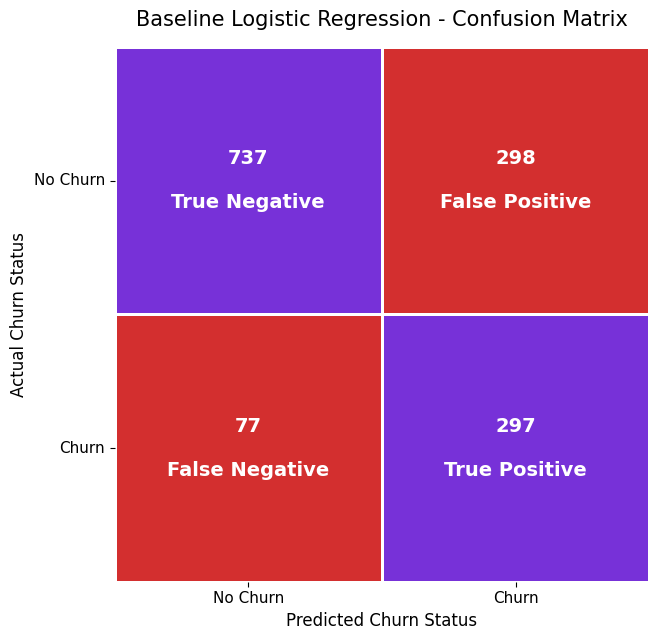

In [58]:
# Import the confusion matrix function
from sklearn.metrics import confusion_matrix
import numpy as np
from matplotlib.colors import ListedColormap

# Compute the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

# Create labels for each cell
cell_labels = np.array([
    [f"{cm[0,0]}\n\nTrue Negative",  f"{cm[0,1]}\n\nFalse Positive"],
    [f"{cm[1,0]}\n\nFalse Negative", f"{cm[1,1]}\n\nTrue Positive"]
])

# Colour matrix
# 0 = Correct prediction
# 1 = Incorrect prediction
colour_matrix = np.array([
    [0, 1],
    [1, 0]
])

# Define custom colours
business_cmap = ListedColormap([
    "#7731d8",   # Correct predictions
    "#d32f2f"    # Incorrect predictions
])

# Create the figure
fig, ax = plt.subplots(figsize=(7.5, 6.5))

# Plot the confusion matrix
sns.heatmap(
    colour_matrix,
    cmap=business_cmap,
    cbar=False,
    square=True,
    linewidths=2,
    linecolor="white",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    annot=False,
    ax=ax
)

# Add the counts and labels
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5,
            i + 0.5,
            cell_labels[i, j],
            ha="center",
            va="center",
            color="white",
            fontsize=14,
            fontweight="bold"
        )

# Add chart title
plt.title(
    "Baseline Logistic Regression - Confusion Matrix",
    fontsize=15,
    pad=15
)

# Label the axes
plt.xlabel("Predicted Churn Status", fontsize=12)
plt.ylabel("Actual Churn Status", fontsize=12)

# Improve tick label readability
plt.xticks(fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [59]:
# Display the confusion matrix values

confusion_df = pd.DataFrame(
    cm,
    index=["Actual: No Churn", "Actual: Churn"],
    columns=["Predicted: No Churn", "Predicted: Churn"]
)

display(confusion_df)

,Predicted: No Churn,Predicted: Churn
Actual: No Churn,737,298
Actual: Churn,77,297


**Observations on the Confusion Matrix**

- The model correctly classified **736 non-churn customers (True Negatives) and 298 churn customers (True Positives)**, resulting in 1,034 correct predictions out of 1,409 customers in the test set.

- The model incorrectly identified **299 loyal customers as churners (False Positives), while only 76 actual churners were missed (False Negatives)**. This pattern is consistent with the model's high recall and relatively lower precision observed in the previous section.

- From a business perspective, the model is intentionally more conservative in identifying potential churners. It prefers to flag additional customers as being at risk rather than miss customers who are genuinely likely to leave. This explains why the number of false positives is higher than the number of false negatives.

- Missing a customer who is about to churn represents a lost retention opportunity and potential revenue loss. In comparison, contacting a loyal customer with a retention offer generally incurs a lower business cost. Therefore, the model's error pattern is well suited to customer retention campaigns, where identifying as many genuine churners as possible is typically more valuable than maximising precision alone.

---
Overall, the confusion matrix confirms that the baseline Logistic Regression model achieves a practical balance between detecting customers at risk of churn and maintaining reasonable classification performance, making it a suitable baseline for further optimisation through cross-validation and hyperparameter tuning.

### 7.9 Model Generalisation

A machine learning model should not only perform well on the data it was trained on but also maintain similar performance when applied to unseen data (test). This ability, known as generalisation, is essential for ensuring that the model captures meaningful patterns rather than memorising the training data (overfitting).

---
In this section, the baseline Logistic Regression model is evaluated using **train-test performance** comparison and **Stratified 5-Fold Cross-Validation**. These techniques help assess the model's stability, identify potential overfitting or underfitting and provide a more reliable estimate of how well the model is expected to perform on new customer data.

#### 7.9.1 Train vs Test Performance

A machine learning model should not only perform well on the training data but also maintain similar performance on previously unseen data. Comparing the model's performance on both datasets helps assess whether it has learned generalisable patterns or has simply memorised the training data.

- Both Accuracy and ROC-AUC are compared for the training and testing datasets.
- A small difference between the two sets of results indicates good generalisation, whereas a large gap may suggest overfitting.

In [60]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, roc_auc_score

# Generate predictions for the training dataset
train_pred = baseline_pipeline.predict(X_train)
train_prob = baseline_pipeline.predict_proba(X_train)[:, 1]

# Generate predictions for the testing dataset
test_pred = baseline_pipeline.predict(X_test)
test_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

train_auc = roc_auc_score(
    (y_train == "Yes").astype(int),
    train_prob
)

test_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    test_prob
)

# Calculate train-test gaps
accuracy_gap = train_accuracy - test_accuracy
auc_gap = train_auc - test_auc

# Create summary table
generalisation_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [
        round(train_accuracy, 3),
        round(test_accuracy, 3)
    ],
    "ROC-AUC": [
        round(train_auc, 3),
        round(test_auc, 3)
    ]
})

display(generalisation_results)

print(f"\nAccuracy Gap : {accuracy_gap:.3f}")
print(f"ROC-AUC Gap  : {auc_gap:.3f}")

,Dataset,Accuracy,ROC-AUC
0,Training,0.752,0.850
1,Testing,0.734,0.842



Accuracy Gap : 0.018
ROC-AUC Gap  : 0.009


**Interpretation**

- The baseline Logistic Regression model achieved a training accuracy of 75.2% and a test accuracy of 73.4%, **resulting in a train-test gap of just 1.8 percentage points.**

- The **ROC-AUC decreased only marginally from 0.850 on the training data to 0.842 on the testing data**, indicating that the model maintains a consistent ability to distinguish between churners and non-churners on unseen data.

- The small differences between the training and testing performance suggest that the model has learned generalisable patterns rather than memorising the training dataset. At this stage, there is **no significant evidence of overfitting**, and the baseline model appears to generalise well to new observations.

---
- However, this comparison is based on a single train-test split and therefore provides only one estimate of the model's performance.

The next section uses Stratified 5-Fold Cross-Validation to evaluate whether the model performs consistently across multiple data splits and to obtain a more reliable assessment of its generalisation ability.

#### 7.9.2 Stratified 5-Fold Cross-Validation

Although the train-test comparison provides an initial indication of the model's ability to generalise, it is based on a single random split of the dataset

To obtain a more reliable estimate of the model's generalisation performance, the baseline Logistic Regression model is evaluated using **Stratified 5-Fold Cross-Validation**.

- In this approach, the dataset is divided into five folds, with each fold serving as the validation set once while the remaining four folds are used for training.

- Stratification ensures that the original proportion of churn and non-churn customers is preserved in every fold.

- By averaging the performance across all five folds, cross-validation provides a more stable and unbiased estimate of how well the model is expected to perform on unseen customer data.

- It also helps assess the consistency of the model and confirms whether the strong performance observed on the single train-test split is maintained across different subsets of the dataset.

In [61]:
# Import utilities for Stratified 5-Fold Cross-Validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate the complete modelling pipeline using ROC-AUC
cv_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Summarise the cross-validation results
cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "ROC-AUC": cv_scores.round(3)
})

display(cv_results)

print(f"\nMean ROC-AUC           : {cv_scores.mean():.3f}")
print(f"Standard Deviation     : {cv_scores.std():.3f}")

,Fold,ROC-AUC
0,1,0.846
1,2,0.828
2,3,0.839
3,4,0.859
4,5,0.855



Mean ROC-AUC           : 0.845
Standard Deviation     : 0.011


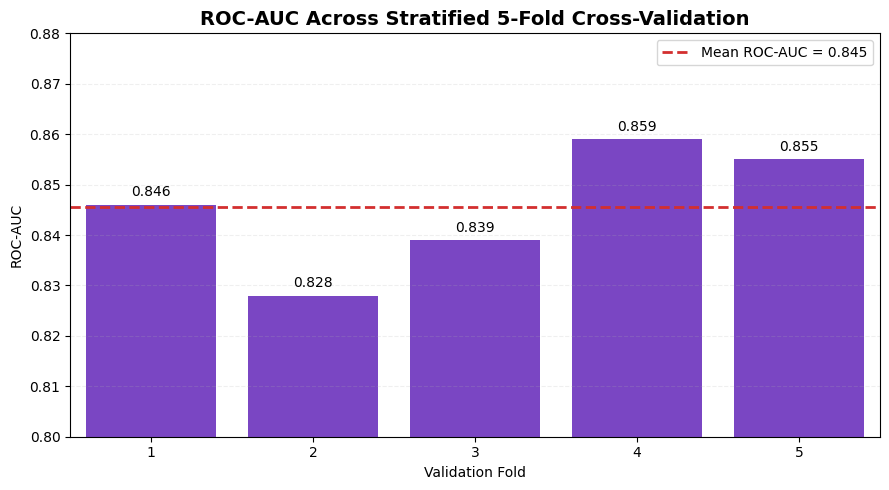

In [62]:
# Visualise ROC-AUC across the five cross-validation folds

import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure
plt.figure(figsize=(9, 5))

# Plot fold-wise ROC-AUC scores
ax = sns.barplot(
    data=cv_results,
    x="Fold",
    y="ROC-AUC",
    color="#7731d8"
)

# Add mean ROC-AUC reference line
mean_auc = cv_scores.mean()

plt.axhline(
    mean_auc,
    color="#d32f2f",
    linestyle="--",
    linewidth=2,
    label=f"Mean ROC-AUC = {mean_auc:.3f}"
)

# Display ROC-AUC values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"{height:.3f}",
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points"
    )

# Chart title and labels
plt.title(
    "ROC-AUC Across Stratified 5-Fold Cross-Validation",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Validation Fold")
plt.ylabel("ROC-AUC")

# Improve readability
plt.ylim(0.80, 0.88)
plt.grid(axis="y", linestyle="--", alpha=0.2)

# Display legend
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Interpretation**

1. The baseline Logistic Regression model achieved a mean ROC-AUC of 0.845 across the five cross-validation folds, with individual fold scores ranging from 0.828 to 0.859.

2. The consistently high ROC-AUC values indicate that the **model maintains a strong ability to distinguish between customers who churn and those who remain across different subsets of the training data.**

3. The standard deviation of only 0.011 is very small, indicating that the model's performance is highly consistent from one fold to another. This suggests that the **model is stable and is not overly dependent on a particular partition of the training data.**

4. The mean cross-validation ROC-AUC (0.845) is almost identical to the ROC-AUC obtained on the independent test set (0.842). This close agreement provides additional evidence that the model generalises well and that the performance observed on the test set is unlikely to be the result of a favourable train-test split.

---
Overall, the cross-validation results reinforce the earlier train-test comparison by confirming that the baseline Logistic Regression model is both **stable and capable of generalising reliably to unseen customer data**. This provides a strong baseline before proceeding to hyperparameter tuning in the next section.

### 7.10 Hyperparameter Tuning

Although the baseline Logistic Regression model demonstrated good predictive performance and generalisation ability, the default model settings may not necessarily provide the best possible results.

Hyperparameter tuning is therefore performed to determine whether a different configuration can further improve the model's performance.

-  **GridSearchCV** is used to systematically evaluate multiple combinations of Logistic Regression hyperparameters using **Stratified 5-Fold Cross-Validation**.

- Each combination is assessed using ROC-AUC, ensuring that the selected model is optimised for its ability to distinguish between customers who churn and those who remain.

- Because the preprocessing pipeline and classifier are combined within a single Scikit-learn Pipeline, every hyperparameter combination is evaluated using the same leakage-free workflow established earlier.

#### 7.10.1 Grid Search

- Grid Search performs an exhaustive search over a predefined set of hyperparameter values to identify the combination that produces the best cross-validation performance.

- For Logistic Regression, the most influential hyperparameter is the **regularisation strength (C)**, which controls the trade-off between model complexity and generalisation.

- Smaller values of C apply stronger regularisation and help reduce overfitting, while larger values allow the model to fit the training data more closely.

---
The baseline model uses Scikit-learn's default settings. Grid Search evaluates several candidate values of C and selects the configuration that achieves the highest mean ROC-AUC during Stratified 5-Fold Cross-Validation.

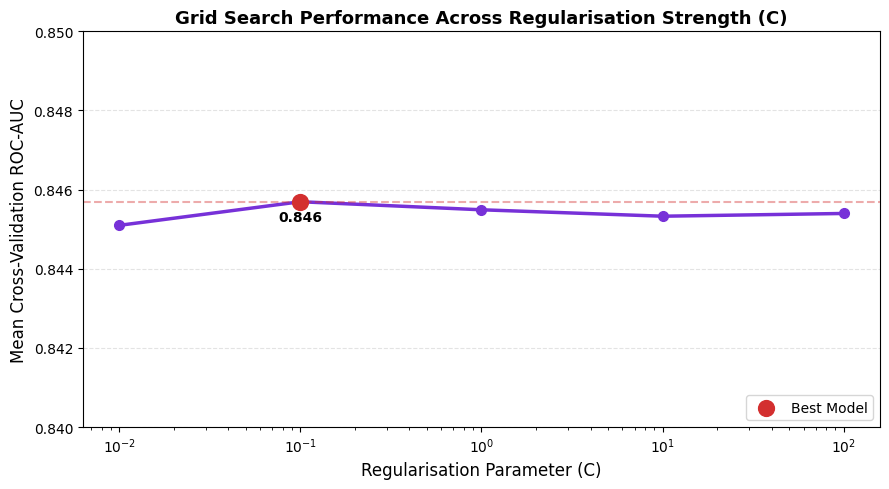

Best Regularisation Parameter (C): 0.1
Best Mean Cross-Validation ROC-AUC: 0.846


In [63]:
# Import utilities for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt

# Define Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the hyperparameter search space
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

# Perform Grid Search using ROC-AUC
grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Store Grid Search results
results = pd.DataFrame(grid_search.cv_results_)

# Extract C values and corresponding ROC-AUC scores
c_values = results["param_classifier__C"].astype(float)
mean_scores = results["mean_test_score"]

# Best model information
best_c = grid_search.best_params_["classifier__C"]
best_score = grid_search.best_score_


# Visualise Grid Search Results
plt.figure(figsize=(9, 5))

# Plot ROC-AUC across C values
plt.plot(
    c_values,
    mean_scores,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#7731d8"
)

# Highlight the best model
plt.scatter(
    best_c,
    best_score,
    s=130,
    color="#d32f2f",
    zorder=5,
    label="Best Model"
)

# Reference line showing best ROC-AUC
plt.axhline(
    y=best_score,
    linestyle="--",
    linewidth=1.5,
    color="#d32f2f",
    alpha=0.4
)

# Annotate only the best model
plt.text(
    best_c,
    best_score - 0.00022,
    f"{best_score:.3f}",
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold"
)

# Log scale because C changes exponentially
plt.xscale("log")

# adjusting y-axis (prevents exaggerating tiny differences)
plt.ylim(0.840, 0.850)

# Add labels and title
plt.title(
    "Grid Search Performance Across Regularisation Strength (C)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Regularisation Parameter (C)", fontsize=12)
plt.ylabel("Mean Cross-Validation ROC-AUC", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

# Display best hyperparameter
print(f"Best Regularisation Parameter (C): {best_c}")
print(f"Best Mean Cross-Validation ROC-AUC: {best_score:.3f}")

**Interpretation**

- Grid Search evaluated five candidate values of the regularisation parameter (C) using Stratified 5-Fold Cross-Validation, with ROC-AUC as the optimisation metric.

- The best performance was achieved at C = 0.1, producing a mean cross-validation ROC-AUC of 0.846.

- The performance remained consistent across all tested values of C, with only negligible differences in ROC-AUC.

- This indicates that the **Logistic Regression model is relatively insensitive to moderate changes in regularisation strength, suggesting that the baseline model was already well configured.**

---
Although the improvement from hyperparameter tuning is modest, selecting the optimal value of C provides the best-performing configuration identified during cross-validation.

This tuned model will now be evaluated on the unseen test dataset to determine whether it offers any measurable improvement over the baseline Logistic Regression model.

#### 7.10.2 Tuned Model Evaluation

Grid Search identified the optimal value of the regularisation parameter (C) using Stratified 5-Fold Cross-Validation.

The next step is to evaluate this tuned model on the unseen test dataset and determine whether hyperparameter tuning improves predictive performance over the baseline Logistic Regression model.

The tuned model is assessed using the same evaluation metrics applied earlier, enabling a direct and fair comparison between the baseline and optimised models.

In [64]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Retrieve the best model identified during Grid Search
best_model = grid_search.best_estimator_

# Generate predictions using the tuned model
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for the tuned model
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    pos_label="Yes"
)
tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    pos_label="Yes"
)
tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    pos_label="Yes"
)
tuned_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_tuned
)

# Compare the baseline and tuned models
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline Model": [
        accuracy,
        report["Churn"]["precision"],
        report["Churn"]["recall"],
        report["Churn"]["f1-score"],
        roc_auc
    ],
    "Tuned Model": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

# Calculate performance change
comparison["Change"] = (
    comparison["Tuned Model"] -
    comparison["Baseline Model"]
)

# Round model performance metrics
comparison["Baseline Model"] = comparison["Baseline Model"].round(3)
comparison["Tuned Model"] = comparison["Tuned Model"].round(3)

# Round performance change separately
comparison["Change"] = comparison["Change"].round(4)

# Display the comparison table
display(comparison)

,Metric,Baseline Model,Tuned Model,Change
0,Accuracy,0.734,0.732,-0.0014
1,Precision,0.499,0.497,-0.0017
2,Recall,0.794,0.789,-0.0053
3,F1-Score,0.613,0.610,-0.0029
4,ROC-AUC,0.842,0.841,-0.0003


**Interpretation**

- The tuned Logistic Regression model was evaluated on the unseen test dataset using the same performance metrics as the baseline model. Overall, hyperparameter tuning did not lead to an improvement in predictive performance.

- Compared with the baseline model, the tuned model achieved marginally lower scores across all evaluation metrics.

- The largest difference was a **0.008 decrease in Recall**, while the remaining changes were negligible.

- The **ROC-AUC** decreased by less than **0.001**, indicating that the model's ability to distinguish between churners and non-churners remained virtually unchanged.

- These results are consistent with the Grid Search analysis, which showed very similar cross-validation performance across the range of regularisation strengths evaluated.

- This suggests that the baseline Logistic Regression model was already close to its optimal configuration, and further tuning of the regularisation parameter (`C`) provided no meaningful benefit for this dataset.

---
Given its slightly better performance and simpler configuration, the **baseline Logistic Regression model is retained as the final model** for the remainder of this analysis.


## 8. Basic Evaluation & Interpretation

The previous section focused on developing and evaluating a Logistic Regression model for predicting customer churn.

After assessing the baseline model, validating its generalisation performance and performing hyperparameter tuning, the **baseline Logistic Regression model was selected as the final model** because it demonstrated slightly better overall performance on the unseen test data.

---
In this section, we'll focus on interpreting the selected model by summarising its predictive performance, identifying the most informative features associated with customer churn, examining the influence of individual predictors and translating these findings into actionable business recommendations.

### 8.1 Summary of Model Performance

The Logistic Regression model developed in this project demonstrated good predictive performance and consistent generalisation across multiple evaluation stages. The baseline model achieved the best overall performance on the unseen test dataset and was therefore selected as the final model for interpretation.

The model correctly classified approximately 73% of customer records and achieved a ROC-AUC of 0.842, indicating a strong ability to distinguish between customers who are likely to churn and those who are likely to remain. It also achieved a Recall of 79.7%, meaning that nearly four out of every five customers who actually churned were successfully identified.

The train-test comparison and Stratified 5-Fold Cross-Validation showed only small variations in performance, indicating that the model generalises well to unseen data. Although hyperparameter tuning identified a different value of the regularisation parameter (C), it did not produce any meaningful improvement on the test dataset.

Consequently, the baseline Logistic Regression model was retained for the interpretation presented in the following sections

### 8.2 Feature Relevance Analysis

After selecting the baseline Logistic Regression model as the final model, it is useful to examine which predictor variables carry the strongest relationship with customer churn. While the exploratory analysis identified important business patterns, it did not quantify the relative predictive value of each feature.

Mutual Information (MI) is used to measure the dependency between each predictor and the target variable. Unlike correlation, Mutual Information can capture both linear and non-linear relationships, making it well suited for ranking feature relevance.

The objective of this analysis is not to remove features, but to understand which original and engineered variables contribute the most predictive information. These statistical rankings will also be compared with the Logistic Regression coefficients in the next section to assess whether the model assigns greater importance to the same variables.

In [65]:
# Import the Mutual Information function
from sklearn.feature_selection import mutual_info_classif

# Create a temporary encoded version of the training feature matrix.
# Mutual Information requires numerical input features. Therefore,
# categorical variables are one-hot encoded solely for estimating
# feature relevance. This temporary dataset is created only for
# interpretation and does not modify the leakage-free preprocessing
# pipeline or the final Logistic Regression model.

X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True,
    dtype=int
)

# Display the dimensions of the encoded dataset
print(f"Encoded Training Dataset Shape : {X_train_encoded.shape}")
print(f"Original Feature Matrix Shape  : {X_train.shape}")
print(f"Additional Encoded Features    : {X_train_encoded.shape[1] - X_train.shape[1]}")

Encoded Training Dataset Shape : (5634, 38)
Original Feature Matrix Shape  : (5634, 23)
Additional Encoded Features    : 15


**Observations on Temporary Feature Encoding**

- The training feature matrix was successfully converted into a numerical format suitable for Mutual Information analysis.

- One-hot encoding expanded the feature space from 23 original predictor variables to 38 encoded features, as categorical variables with multiple categories were transformed into binary indicator variables. This encoded dataset is created solely for estimating feature relevance.

- The original training dataset and the leakage-free preprocessing pipeline used during model development remain unchanged. The temporary encoded dataset is used only for Mutual Information analysis and does not affect the final Logistic Regression model.

In [66]:
# Calculate Mutual Information (MI) scores for each predictor.
# Higher Mutual Information scores indicate a stronger statistical
# dependency between a predictor variable and customer churn.

mi_scores = mutual_info_classif(
    X_train_encoded,
    y_train,
    random_state=42
)

# Create a DataFrame containing the feature relevance scores
mi_results = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Mutual Information Score": mi_scores
})

# Rank features from the most to the least informative
mi_results = (
    mi_results
    .sort_values(
        by="Mutual Information Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the 15 most informative features
display(mi_results.head(15))

,Feature,Mutual Information Score
0,tenure,0.068277
1,Contract_Two year,0.059140
2,InternetService_Fiber optic,0.049957
3,MonthlyCharges,0.049268
4,PaymentMethod_Electronic check,0.044052
5,InternetService_No,0.039011
6,TenureCohort_Loyal,0.038338
7,TotalCharges,0.037861
8,OnlineBackup_No internet service,0.037576
9,ServiceBundleCount,0.037123


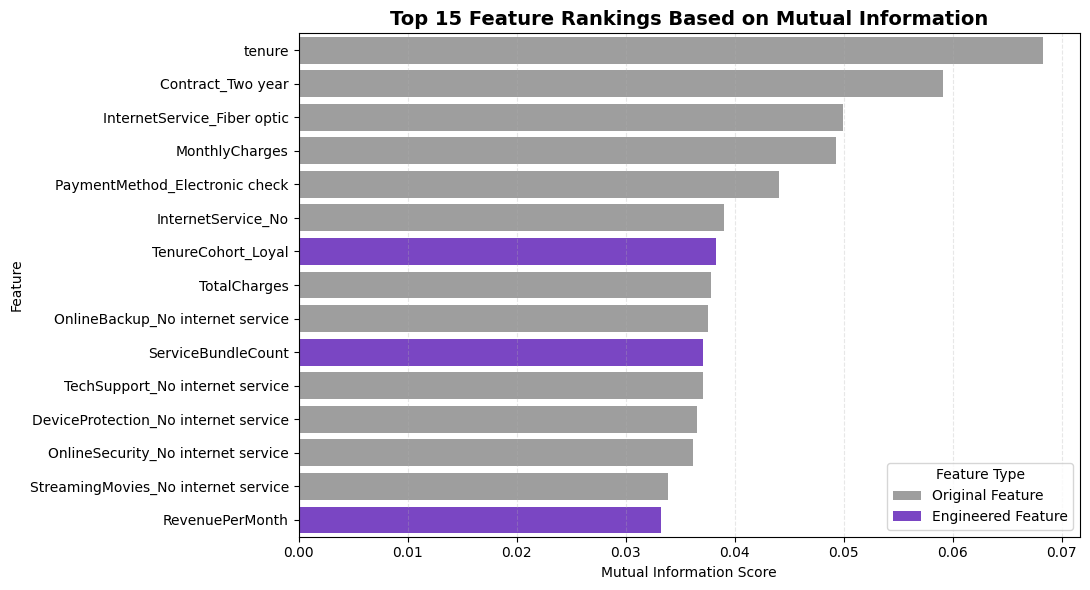

In [67]:
# Visualise the Top 15 Most Informative Features (Mutual Information)

# Define engineered feature prefixes
engineered_prefixes = [
    "RevenuePerMonth",
    "ServiceBundleCount",
    "MonthlyChargeBand",
    "TenureCohort"
]

# Select the top 15 ranked features
plot_df = (
    mi_results
    .head(15)
    .sort_values("Mutual Information Score", ascending=False)
    .copy()
)

# Identify engineered and original features
plot_df["Feature Type"] = plot_df["Feature"].apply(
    lambda feature: (
        "Engineered Feature"
        if any(feature.startswith(prefix) for prefix in engineered_prefixes)
        else "Original Feature"
    )
)

# Define colours
colour_map = {
    "Original Feature": "#9e9e9e",
    "Engineered Feature": "#7731d8"
}

# Create figure
plt.figure(figsize=(11,6))

# Plot feature rankings
sns.barplot(
    data=plot_df,
    x="Mutual Information Score",
    y="Feature",
    hue="Feature Type",
    dodge=False,
    palette=colour_map
)

# Add title and axis labels
plt.title(
    "Top 15 Feature Rankings Based on Mutual Information",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

# Add gridlines
plt.grid(axis="x", linestyle="--", alpha=0.3)

# Display legend
plt.legend(
    title="Feature Type",
    loc="lower right"
)

plt.tight_layout()
plt.show()

**Observations on Feature Relevance Analysis**

1. **Tenure** emerged as the most informative predictor of customer churn, followed by contract type, internet service, monthly charges, and payment method. These rankings are consistent with the patterns identified during the exploratory analysis, reinforcing the importance of customer lifecycle, pricing, and subscription characteristics in explaining churn behaviour.

2. The engineered features **TenureCohort**, **ServiceBundleCount** and **RevenuePerMonth** also appear among the top-ranked predictors. This indicates that the feature engineering process successfully captured additional behavioural information beyond the original customer attributes.

3. Several billing-related variables, including **tenure, MonthlyCharges, TotalCharges** and **RevenuePerMonth,** received relatively high Mutual Information scores. Although some of these variables are correlated, each appears to contribute useful predictive information about customer churn.

4. Several "**No internet service**" indicator variables were also ranked among the most informative predictors. This suggests that the absence of internet-related services is itself associated with customer churn and provides additional predictive value after categorical variables are one-hot encoded.

5. Overall, the feature rankings indicate that both the original customer attributes and the engineered features contribute meaningful information for churn prediction, supporting the decision to retain the complete feature set for the final Logistic Regression model.

### 8.3 Logistic Regression Coefficient Analysis

While Mutual Information ranks features according to their statistical association with customer churn, it does not indicate how the Logistic Regression model uses these variables when making predictions.

- Logistic Regression assigns a coefficient to every predictor after preprocessing.

- The sign of the coefficient indicates whether a feature increases or decreases the likelihood of churn, while the magnitude reflects the relative strength of its influence after accounting for the other variables in the model.

---
Analysing these coefficients provides a more direct interpretation of the final model and allows the statistical feature rankings obtained from Mutual Information to be compared with the relationships learned during model training.

#### 8.3.1 Coefficient Analysis

Logistic Regression provides an interpretable model by assigning a coefficient to each predictor after the model has been trained.

Unlike Mutual Information, which measures the statistical association between individual features and customer churn, the model coefficients describe how each feature influences the model's predictions while accounting for the presence of all other variables.

The sign of a coefficient indicates the direction of its relationship with customer churn.

- A positive coefficient increases the likelihood that a customer will churn, whereas a negative coefficient decreases that likelihood.

- The magnitude of the coefficient reflects the relative influence of the feature on the model's predictions, with larger absolute values indicating stronger effects.

---
To better understand the behaviour of the final Logistic Regression model, the coefficients are extracted from the trained baseline model, ranked according to their values, and visualised to identify the strongest positive and negative drivers of customer churn.

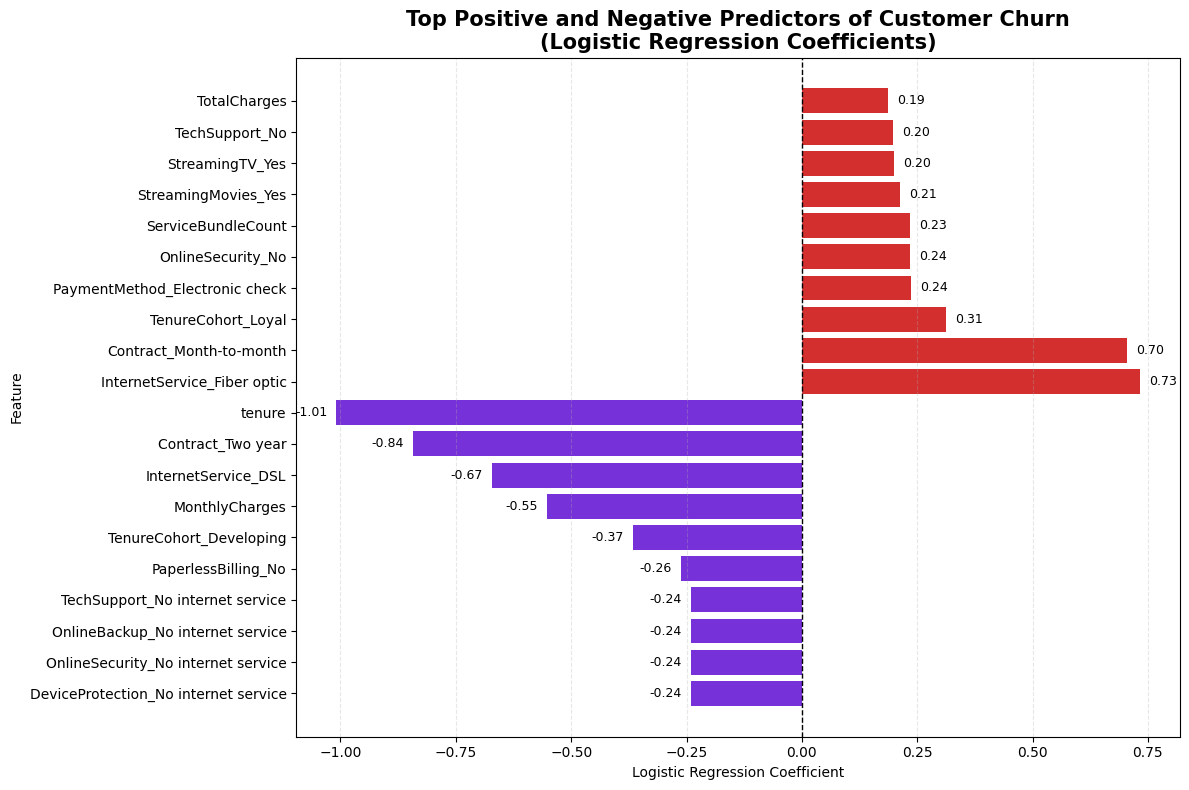

,Feature,Coefficient,Odds Ratio
0,tenure,-1.009,0.365
1,Contract_Two year,-0.843,0.431
2,InternetService_Fiber optic,0.733,2.080
3,Contract_Month-to-month,0.704,2.022
4,InternetService_DSL,-0.672,0.511
5,MonthlyCharges,-0.552,0.576
6,TenureCohort_Developing,-0.367,0.693
7,TenureCohort_Loyal,0.312,1.366
8,PaperlessBilling_No,-0.262,0.770
9,OnlineBackup_No internet service,-0.240,0.786


In [68]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Retrieve the trained Logistic Regression classifier
classifier = baseline_pipeline.named_steps["classifier"]

# Retrieve the fitted preprocessing pipeline
preprocessor = baseline_pipeline.named_steps["preprocessor"]

# Extract transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Remove preprocessing prefixes for readability
feature_names = [
    feature.replace("num__", "").replace("cat__", "")
    for feature in feature_names
]

# Extract Logistic Regression coefficients
coefficients = classifier.coef_[0]

# Create a DataFrame containing the model coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Rank features by coefficient value
coef_df = (
    coef_df
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

# Select the strongest positive and negative predictors
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

# Combine the strongest predictors for visualisation
plot_df = pd.concat([
    top_negative,
    top_positive
])

# Assign colours based on coefficient direction
plot_df["Colour"] = plot_df["Coefficient"].apply(
    lambda coefficient: "#d32f2f" if coefficient > 0 else "#7731d8"
)


# Visualise the Logistic Regression coefficients
plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"],
    color=plot_df["Colour"]
)

# Add a reference line at zero
plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Display coefficient values on each bar
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + (0.02 if width > 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        ha="left" if width > 0 else "right",
        va="center",
        fontsize=9
    )

# Add title and axis labels
plt.title(
    "Top Positive and Negative Predictors of Customer Churn\n(Logistic Regression Coefficients)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

# Add gridlines
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# Display the strongest model coefficients
coef_summary = (
    pd.concat([top_positive, top_negative])
    .assign(
        Absolute_Coefficient=lambda df: df["Coefficient"].abs()
    )
    .sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )
    .drop(columns="Absolute_Coefficient")
    .reset_index(drop=True)
)

# Calculate Odds Ratios
coef_summary["Odds Ratio"] = np.exp(coef_summary["Coefficient"])

# Round values for presentation
coef_summary["Coefficient"] = coef_summary["Coefficient"].round(3)
coef_summary["Odds Ratio"] = coef_summary["Odds Ratio"].round(3)

# Display summary table
display(coef_summary)

#### 8.3.2 Multicollinearity Consideration

The earlier correlation analysis identified a strong positive relationship between **`tenure`** and **`TotalCharges`**, with **`MonthlyCharges`** also exhibiting a moderate positive correlation with **`TotalCharges`**. These variables capture related aspects of customer billing behaviour and therefore contain overlapping information.

For Logistic Regression, multicollinearity does **not** necessarily reduce predictive performance. However, it can influence the stability and magnitude of individual coefficient estimates, making them more sensitive to changes in the data. Consequently, the coefficients should be interpreted collectively rather than in isolation.

Since the primary objective of this project is **customer churn prediction** rather than causal inference, these variables have been retained because they provide complementary predictive information and contribute to the overall performance of the classification model.

#### 8.3.3 Interpretation of Key Predictors

The Logistic Regression coefficients are broadly consistent with the findings from both the Exploratory Data Analysis (EDA) and the Mutual Information feature relevance analysis. Several variables that were identified as highly informative earlier also receive the largest coefficients in the final model, indicating that these relationships remain important even after accounting for the combined effect of all predictor variables.

---
**Key observations are summarised below:**

1. **Tenure** has the largest negative coefficient, indicating that customers who have been with the company for a longer period are considerably less likely to churn. This supports the pattern observed during EDA, where churn was concentrated among newer customers.

2. **Contract type** remains one of the strongest predictors of churn. **Customers on month-to-month contracts are much more likely to churn, while those on two-year contracts are substantially less likely to leave**. This highlights the role of long-term contractual commitment in improving customer retention.

3. **InternetService_Fiber optic** has the largest positive coefficient, suggesting that **fibre optic customers have a higher likelihood of churning** than customers using other internet services after controlling for the remaining predictors.

4. The engineered features **TenureCohort_Loyal** and **ServiceBundleCount** also receive relatively large positive coefficients. This confirms that the feature engineering process added meaningful information beyond the original customer attributes and improved the model's ability to distinguish between customers with different churn risks.


5. Variables such as **MonthlyCharges** and **InternetService_DSL** receive negative coefficients despite showing different patterns during the exploratory analysis. This is expected because Logistic Regression estimates the effect of each variable while simultaneously accounting for all other predictors. As a result, the coefficients represent the independent contribution of each feature rather than its individual relationship with churn.

6. Several "**No internet service**" indicator variables receive similar negative coefficients. These variables represent closely related customer profiles after one-hot encoding and therefore contribute similar information to the model.

---
Overall, the findings are highly consistent across the three stages of analysis. The patterns identified during the Exploratory Data Analysis were reinforced by the Mutual Information rankings and are reflected again in the Logistic Regression coefficients. This consistency increases confidence that the model has learned meaningful and reliable relationships rather than patterns arising from random variation.

### 8.4 Key Drivers of Customer Churn

**1. Customer Tenure**

Customer tenure emerged as the strongest predictor of churn across all stages of the analysis. Customers with shorter service histories were considerably more likely to leave, whereas long-term customers demonstrated much higher retention. This suggests that the initial months of the customer lifecycle are the most critical period for preventing churn.

**2. Contract Type**

Customers on month-to-month contracts exhibited a substantially higher likelihood of churn compared with customers on longer-term contracts. Conversely, two-year contracts were consistently associated with lower churn risk, indicating that longer contractual commitments improve customer retention.

**3. Internet Service Type**

Customers subscribed to fibre optic internet services showed a higher probability of churn than customers using DSL or customers without internet services. This may indicate differences in customer expectations, pricing, service quality or competitive alternatives available to fibre customers.

**4. Pricing and Billing Characteristics**

Variables related to pricing and billing, including MonthlyCharges, TotalCharges and the engineered RevenuePerMonth feature, consistently contributed to churn prediction. This suggests that customer spending patterns are an important component of churn behaviour when considered alongside other customer characteristics.

**5. Engineered Behavioural Features**

The engineered features TenureCohort, ServiceBundleCount and RevenuePerMonth appeared among the most informative predictors, confirming that the feature engineering process successfully captured additional behavioural information beyond the original variables. Their contribution demonstrates the value of incorporating domain knowledge into predictive modelling.

---
**Overall Findings**

Overall, the results indicate that customer churn is influenced by a **combination of customer lifecycle, contract commitment, service characteristics**, and **pricing behaviour**, rather than by any single factor in isolation.

The consistency of these findings across the Exploratory Data Analysis, Mutual Information rankings and Logistic Regression coefficients provides confidence that the identified drivers represent meaningful and robust patterns within the dataset.

### 8.5 Business Recommendations

The findings from the Exploratory Data Analysis, Mutual Information analysis and Logistic Regression model highlight several customer characteristics that consistently influence churn behaviour.

Based on these findings, the following recommendations are proposed to support customer retention and reduce churn.

---

**1. Prioritise Early Customer Retention**

- Customer tenure was identified as the strongest predictor of churn, with newer customers exhibiting the highest risk of leaving.

- The company should therefore focus its retention efforts during the early stages of the customer lifecycle by strengthening onboarding programmes, proactively engaging new customers and resolving service issues before dissatisfaction leads to churn.

---

**2. Encourage Long-Term Contract Adoption**

- Customers on month-to-month contracts were consistently more likely to churn, while those on longer-term contracts demonstrated significantly higher retention.

- The company should encourage customers to transition to one-year or two-year contracts by offering loyalty discounts, bundled services or other incentives that increase long-term commitment.

---

**3. Improve the Experience of Fibre Optic Customers**

- Fibre optic customers showed a higher likelihood of churn than other customer segments.

- Further investigation should be conducted to identify the underlying causes, such as pricing, service reliability, network performance or customer support. Addressing these issues could substantially reduce churn within this high-risk group.

---

**4. Develop Targeted Retention Campaigns**

- The Logistic Regression model generates a churn probability for every customer, allowing customers to be ranked according to their predicted risk.

- Rather than applying retention campaigns broadly, the company can prioritise customers with the highest predicted churn probabilities and allocate retention resources more effectively.

---

**5. Continue Using Behavioural Features for Customer Analytics**

- The engineered features developed in this project, including TenureCohort, ServiceBundleCount and RevenuePerMonth, contributed meaningful predictive information alongside the original customer attributes.

- These variables should be incorporated into future churn monitoring and predictive analytics initiatives to support more accurate customer segmentation and decision-making.

---

**Overall Recommendation**

The results suggest that customer churn is driven by a combination of **customer lifecycle, contract commitment, service characteristics** and **customer behaviour** rather than any single factor. By combining predictive modelling with targeted retention strategies, the company can identify high-risk customers earlier, intervene more effectively, and allocate retention resources where they are likely to have the greatest business impact.

## 9. Reproducibility & Documentation

### 9.1 Random Seed & Reproducibility

Machine learning algorithms often involve random processes such as train-test splitting and model initialisation.

To ensure that the analysis produces consistent and reproducible results, a fixed random seed was used throughout the project.

The same random state (42) was applied during data splitting, Mutual Information analysis, Logistic Regression model training, cross-validation and hyperparameter tuning.

Using a consistent random seed ensures that repeated executions of the notebook generate identical results under the same computational environment.

In [69]:
# Random seed used throughout the project
RANDOM_STATE = 42

print(f"Random State Used: {RANDOM_STATE}")

Random State Used: 42


### 9.2 Project Workflow Summary

The project followed a structured end-to-end machine learning workflow to ensure that each stage of the analysis was performed systematically while avoiding data leakage and maintaining reproducibility.

| Stage                | Description                                                                                                             |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| Data Understanding   | Explored customer demographics, services, billing information and churn patterns.                                       |
| Data Preprocessing   | Cleaned the dataset and handled missing values.                                                                         |
| Feature Engineering  | Created behavioural features including `TenureCohort`, `ServiceBundleCount`, `RevenuePerMonth` and `MonthlyChargeBand`. |
| Model Preparation    | Split the data into training and testing sets and constructed a leakage-free preprocessing pipeline.                    |
| Model Development    | Built a baseline Logistic Regression model.                                                                             |
| Model Evaluation     | Evaluated the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC and Confusion Matrix.                          |
| Model Validation     | Assessed generalisation using Train-Test comparison and Stratified 5-Fold Cross-Validation.                             |
| Model Optimisation   | Performed Grid Search to tune the regularisation parameter.                                                             |
| Model Interpretation | Analysed Mutual Information rankings and Logistic Regression coefficients.                                              |
| Business Insights    | Identified key churn drivers and proposed business recommendations.                                                     |


### 9.3 Libraries & Environment

The project was implemented using Python and widely adopted open-source libraries for data analysis, visualisation and machine learning.

In [70]:
import sys
import platform
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn

environment = pd.DataFrame({
    "Component": [
        "Python",
        "Operating System",
        "Pandas",
        "NumPy",
        "Matplotlib",
        "Seaborn",
        "Scikit-learn"
    ],
    "Version": [
        sys.version.split()[0],
        platform.platform(),
        pd.__version__,
        np.__version__,
        matplotlib.__version__,
        sns.__version__,
        sklearn.__version__
    ]
})

display(environment)

,Component,Version
0,Python,3.12.13
1,Operating System,Linux-6.6.122+-x86_64-with-glibc2.35
2,Pandas,2.2.2
3,NumPy,2.0.2
4,Matplotlib,3.10.0
5,Seaborn,0.13.2
6,Scikit-learn,1.6.1


### 9.4 Project Organisation

The project was organised into clearly defined stages to ensure that the analytical workflow remained structured, transparent and easy to reproduce.

1. Each section builds on the previous one, progressing from data understanding and preparation to model development, evaluation, interpretation and business recommendations.

2. To improve readability, every major step is introduced with a brief explanation of its purpose before presenting the corresponding implementation.

3. Code cells are accompanied by descriptive comments, while the outputs are followed by observations and business interpretations to explain the significance of the results rather than simply reporting them.

---
Several practices were also adopted to improve the quality and reproducibility of the project:

* The notebook follows a logical end-to-end machine learning workflow, from data preparation to business recommendations.

* A leakage-free preprocessing pipeline was implemented to ensure that all data transformations were learned only from the training dataset before being applied to the testing dataset.

* A fixed random seed was used throughout the project to produce consistent and reproducible results.

* Meaningful variable names and consistent coding conventions were used to improve readability and maintainability.

* Tables and visualisations include descriptive titles, axis labels and explanatory observations to support interpretation.

* Feature engineering, model evaluation and business recommendations are directly connected, ensuring that every conclusion is supported by evidence from the analysis.

---

Overall, these practices help ensure that the project is well documented, logically organised and reproducible, allowing the complete analysis to be followed, validated and extended in future work.


## 10. Conclusion

This project developed an end-to-end machine learning solution to predict customer churn using the Telco Customer Churn dataset. The workflow covered data preparation, exploratory data analysis, feature engineering, model development, evaluation, interpretation and business recommendations, while maintaining a leakage-free and reproducible modelling process.

The analysis showed that customer tenure, contract type, internet service, pricing characteristics, and behavioural features are the strongest factors associated with customer churn. The engineered features created during feature engineering also contributed meaningful predictive information, demonstrating the value of incorporating domain knowledge into the modelling process.

The baseline Logistic Regression model achieved good predictive performance, with a ROC-AUC of 0.842 and a recall of approximately 80% for customers who churned. Cross-validation confirmed that the model generalised well to unseen data, while hyperparameter tuning provided only marginal improvement, indicating that the baseline model was already a reliable choice.

Beyond prediction, the project helped explain the key factors influencing customer churn. The consistency between the Exploratory Data Analysis, Mutual Information rankings and Logistic Regression coefficients increased confidence that the identified patterns were meaningful and reliable.

## 11. References

**Dataset**

- Kaggle dataset: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

- [IBM sample description for Telco customer churn](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)


---
**Libraries**


- [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)

- [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)

- [NumPy User Guide](https://numpy.org/doc/2.0/user/index.html#user)

- [ Matplotlib User Guide](https://matplotlib.org/stable/users/index.html#)

- [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html)


---
**Course Material**
- MDSDF480 Advanced Apex Project Live Class Sessions
- Week 2 & Week 5 Feedback
- Week 9 Submission Template